# RAMMs V3

RAMMs V3 models a reconfigurable architected mechanical metamaterial (RAMM) using three core classes:

- **RAMM_Chain**
  - Contains **n** RAMM units.
  - Stores whether the chain geometry is **valid**.
  - Computes the chain's remaining **degrees of freedom (DoFs)** using a Maxwell–Calladine-inspired Jacobian analysis.

- **RAMM_Unit**
  - Contains four **RAMM_Nodes**.
  - Contains four **RAMM_Struts** (all equal length).
  - The entire unit geometry is determined from a single reference node and the unit's relative rotation.

- **RAMM_Node**
  - Stores the coordinates of a node.
  - Knows its descriptor (e.g., `0T`, `1L`) once assigned to a chain.

- **RAMM_Strut**
  - Connects two RAMM_Nodes.
  - Knows its descriptor (e.g., `0B0L`) and orientation.

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
plt.style.use("seaborn-v0_8-whitegrid")
import plotly.graph_objects as go
import copy
import re
import pprint
import math
from enum import Enum
from plotly.subplots import make_subplots
from collections import Counter
from scipy.optimize import root
from IPython.display import display # for printing things in LaTex
from matplotlib.lines import Line2D
from dataclasses import dataclass
from scipy.optimize import root
from scipy.optimize import least_squares

## Classes

### Custom Error Classes

In [2]:
class InvalidRAMMGeometryError(Exception):
    pass

### Custom RAMMs Classes

In [3]:
class UnitType(Enum):
    RAILED = "railed"
    FREE = "free"

#### RAMM Node

In [4]:
class RAMM_Node:
    """
    A point belonging to a RAMM unit.

    Standard node examples:
        top, right, bottom, left

    Virtual-node examples:
        left rail lower, left rail upper
    """

    def __init__(
        self,
        long_name,
        coordinates,
        short_label=None,
        is_virtual=False
    ):
        self.long_name = long_name

        # Coordinates are stored as (y, z):
        # y = horizontal position
        # z = vertical position
        self.coordinates = coordinates

        # Standard nodes default to the first letter:
        # top -> T, right -> R, etc.
        #
        # Virtual rail nodes receive explicit labels such as:
        # RLL = rail left lower
        self.short_label = (
            short_label
            if short_label is not None
            else long_name[0].upper()
        )

        self.is_virtual = is_virtual
        self.unit_index = None

    @property
    def get_details(self):
        return f"{self.long_name}: {self.coordinates}"

    @property
    def descriptor(self):
        """
        Return a shortened descriptor.

        Examples
        --------
        Standard node:
            top node of Unit 0 -> 0T

        Virtual rail node:
            left rail lower node of Unit 0 -> 0RLL
        """
        return f"{self.unit_index}{self.short_label}"

    def __str__(self):
        return self.descriptor

#### RAMM Strut

In [5]:
class RAMM_Strut:
    """
    A segment connecting two RAMM_Node objects.

    Diamond nodes should be passed in clockwise order.

    Virtual rails are directed from their lower endpoint to their
    upper endpoint.
    """

    def __init__(
        self,
        node_1,
        node_2,
        is_virtual=False,
        segment_type="strut"
    ):
        self.node_1 = node_1
        self.node_2 = node_2

        self.is_virtual = is_virtual
        self.segment_type = segment_type

    @property
    def long_name(self):
        return (
            f"{self.node_1.long_name} -> "
            f"{self.node_2.long_name}"
        )

    @property
    def descriptor(self):
        """
        Return a shortened descriptor.

        Examples
        --------
        Diamond strut:
            Unit 1 bottom -> left = 1B1L

        Virtual left rail:
            Unit 0 rail-left-lower -> rail-left-upper
            = 0RLL0RLU
        """
        return (
            f"{self.node_1.descriptor}"
            f"{self.node_2.descriptor}"
        )

    def __str__(self):
        return self.descriptor

#### RAMM Unit

In [6]:
class RAMM_Unit:
    """
    A four-sided RAMM diamond unit.

    Nodes must be passed clockwise, beginning with the top node.

    RAILED units additionally contain two virtual rail segments.
    FREE units do not contain virtual rails.
    """

    def __init__(
        self,
        top_node,
        right_node,
        bottom_node,
        left_node,
        unit_type,
        node_diameter=2.0,
        rail_nodes=None,
        rails=None
    ):
        self.unit_type = unit_type
        self.node_diameter = float(node_diameter)

        if self.node_diameter <= 0:
            raise ValueError(
                "node_diameter must be greater than zero."
            )

        # ---------------------------------------------------------
        # Physical diamond nodes
        # ---------------------------------------------------------

        self.top_node = top_node
        self.right_node = right_node
        self.bottom_node = bottom_node
        self.left_node = left_node

        self.nodes = [
            top_node,
            right_node,
            bottom_node,
            left_node
        ]

        # Validate only the four diamond nodes.
        self.validate_geometry()

        # ---------------------------------------------------------
        # Physical diamond struts
        # ---------------------------------------------------------

        self.struts = [
            RAMM_Strut(
                top_node,
                right_node,
                is_virtual=False,
                segment_type="diamond_strut"
            ),
            RAMM_Strut(
                right_node,
                bottom_node,
                is_virtual=False,
                segment_type="diamond_strut"
            ),
            RAMM_Strut(
                bottom_node,
                left_node,
                is_virtual=False,
                segment_type="diamond_strut"
            ),
            RAMM_Strut(
                left_node,
                top_node,
                is_virtual=False,
                segment_type="diamond_strut"
            )
        ]

        # ---------------------------------------------------------
        # Virtual rail geometry
        # ---------------------------------------------------------

        self.rail_nodes = (
            list(rail_nodes)
            if rail_nodes is not None
            else []
        )

        self.rails = (
            list(rails)
            if rails is not None
            else []
        )

        if self.unit_type == UnitType.FREE:
            if self.rail_nodes or self.rails:
                raise InvalidRAMMGeometryError(
                    "FREE units cannot contain virtual rails."
                )

        if self.unit_type == UnitType.RAILED:
            if len(self.rail_nodes) != 4:
                raise InvalidRAMMGeometryError(
                    "A RAILED unit must contain four virtual "
                    "rail endpoint nodes."
                )

            if len(self.rails) != 2:
                raise InvalidRAMMGeometryError(
                    "A RAILED unit must contain two virtual rails."
                )

        # Every point that moves rigidly with the unit.
        self.all_nodes = self.nodes + self.rail_nodes

        # Every segment associated with the unit.
        self.all_segments = self.struts + self.rails

        self.rail_length = self._get_rail_length()

    def _get_rail_length(self):
        """
        Return the rail length if this is a RAILED unit.
        """
        if not self.rails:
            return 0.0

        rail = self.rails[0]

        y1, z1 = rail.node_1.coordinates
        y2, z2 = rail.node_2.coordinates

        return math.hypot(
            y2 - y1,
            z2 - z1
        )

    def validate_geometry(self):
        """
        Confirm that all four diamond struts have equal length.

        Virtual rails are intentionally excluded because their length
        is derived separately from the diamond geometry.
        """
        distances = []

        for i in range(4):
            node_1 = self.nodes[i]
            node_2 = self.nodes[(i + 1) % 4]

            y1, z1 = node_1.coordinates
            y2, z2 = node_2.coordinates

            distance = math.hypot(
                y2 - y1,
                z2 - z1
            )

            distances.append(distance)

        if not all(
            math.isclose(
                distance,
                distances[0],
                rel_tol=1e-9,
                abs_tol=1e-9
            )
            for distance in distances
        ):
            raise InvalidRAMMGeometryError(
                "RAMM unit diamond struts must have equal length."
            )

    @staticmethod
    def transform_point(point, pivot, degrees):
        """
        Rotate one (y, z) point counterclockwise around a pivot.
        """
        y, z = point
        pivot_y, pivot_z = pivot

        theta = math.radians(degrees)

        relative_y = y - pivot_y
        relative_z = z - pivot_z

        rotated_y = (
            relative_y * math.cos(theta)
            - relative_z * math.sin(theta)
        )

        rotated_z = (
            relative_y * math.sin(theta)
            + relative_z * math.cos(theta)
        )

        return (
            pivot_y + rotated_y,
            pivot_z + rotated_z
        )

    def transform(self, point, degrees): # TODO: Rename this rotate when you leave notebook
        """
        Rotate the entire rigid unit around a node or arbitrary point.
        """
        if isinstance(point, RAMM_Node):
            pivot = point.coordinates
        else:
            pivot = point

        for node in self.all_nodes:
            node.coordinates = self.transform_point(
                point=node.coordinates,
                pivot=pivot,
                degrees=degrees
            )

    def translate(self, dy=0.0, dz=0.0):
        """
        Translate the entire rigid unit.
        """
        for node in self.all_nodes:
            y, z = node.coordinates

            node.coordinates = (
                y + dy,
                z + dz
            )
    
    def get_rail(self, side):
        """
        Return the requested virtual rail.

        Parameters
        ----------
        side:
            "left" or "right"
        """
        if self.unit_type != UnitType.RAILED:
            raise ValueError(
                "FREE units do not contain rails."
            )

        side = side.lower()

        if side == "left":
            return self.left_rail

        if side == "right":
            return self.right_rail

        raise ValueError(
            "side must be 'left' or 'right'."
        )

    def get_struts_clockwise(self):
        """
        Return the four diamond struts in clockwise order,
        beginning with the top-right strut.

        Order:
            TR, RB, BL, LT
        """
        return list(self.struts)

    def get_strut_by_descriptor(self, descriptor):
        """
        Return the requested diamond strut.

        Example
        -------
        chain.get_strut_by_descriptor("1R1B")
        """
        for strut in self.get_struts_bottom_to_top_clockwise():
            if strut.descriptor == descriptor:
                return strut

        raise ValueError(
            f"No strut with descriptor '{descriptor}' found."
        )

    @classmethod
    def generate(
        cls,
        bottom_position,
        unit_type,
        rotation_deg=0,
        node_diameter=2.0
    ):
        """
        Generate a RAMM unit.

        Parameters
        ----------
        bottom_position:
            Bottom-node position given as (y, z).

        unit_type:
            UnitType.FREE or UnitType.RAILED.

        rotation_deg:
            Counterclockwise rotation in degrees about the bottom node.

        node_diameter:
            Diameter of the node constrained by the rails.

            For RAILED units, the two rail centerlines are positioned
            at +/- node_diameter / 2 from the unit center. Therefore,
            the rail centerlines are separated by node_diameter.
        """

        if node_diameter <= 0:
            raise ValueError(
                "node_diameter must be greater than zero."
            )

        # ---------------------------------------------------------
        # Define all base geometry in one place
        # ---------------------------------------------------------

        local_nodes = {
            "bottom": (0.0, 0.0),
            "right":  (8.0, 10.0),
            "top":    (0.0, 20.0),
            "left":   (-8.0, 10.0)
        }

        bottom_local_y, bottom_local_z = (
            local_nodes["bottom"]
        )

        right_local_y, right_local_z = (
            local_nodes["right"]
        )

        top_local_y, top_local_z = (
            local_nodes["top"]
        )

        left_local_y, left_local_z = (
            local_nodes["left"]
        )

        # The current unit is symmetric about its vertical centerline.
        unit_center_y = (
            bottom_local_y + top_local_y
        ) / 2

        unit_center_z = (
            bottom_local_z + top_local_z
        ) / 2

        diamond_half_width = max(
            abs(right_local_y - unit_center_y),
            abs(left_local_y - unit_center_y)
        )

        diamond_half_height = (
            top_local_z - bottom_local_z
        ) / 2

        # ---------------------------------------------------------
        # Local-to-global coordinate conversion
        # ---------------------------------------------------------

        def create_global_position(local_position):
            """
            Rotate around the local bottom node and then translate to
            the requested global bottom-node position.
            """
            rotated_y, rotated_z = cls.transform_point(
                point=local_position,
                pivot=(0.0, 0.0),
                degrees=rotation_deg
            )

            bottom_y, bottom_z = bottom_position

            return (
                bottom_y + rotated_y,
                bottom_z + rotated_z
            )

        # ---------------------------------------------------------
        # Create the four diamond nodes
        # ---------------------------------------------------------

        bottom_node = RAMM_Node(
            long_name="bottom",
            coordinates=create_global_position(
                local_nodes["bottom"]
            )
        )

        right_node = RAMM_Node(
            long_name="right",
            coordinates=create_global_position(
                local_nodes["right"]
            )
        )

        top_node = RAMM_Node(
            long_name="top",
            coordinates=create_global_position(
                local_nodes["top"]
            )
        )

        left_node = RAMM_Node(
            long_name="left",
            coordinates=create_global_position(
                local_nodes["left"]
            )
        )

        # Defaults for a FREE unit.
        rail_nodes = []
        rails = []

        # ---------------------------------------------------------
        # Generate rails only for a RAILED unit
        # ---------------------------------------------------------

        if unit_type == UnitType.RAILED:
            rail_half_spacing = node_diameter / 2

            if rail_half_spacing >= diamond_half_width:
                raise InvalidRAMMGeometryError(
                    "The requested node diameter is too large "
                    "for the rails to fit inside the diamond."
                )

            # The diamond edge narrows linearly from its widest point
            # toward the top and bottom.
            #
            # At horizontal offset rail_half_spacing:
            #
            # rail_half_length / diamond_half_height
            #     = 1 - rail_half_spacing / diamond_half_width
            rail_half_length = (
                diamond_half_height
                * (
                    1
                    - rail_half_spacing / diamond_half_width
                )
            )

            left_rail_y = (
                unit_center_y - rail_half_spacing
            )

            right_rail_y = (
                unit_center_y + rail_half_spacing
            )

            rail_lower_z = (
                unit_center_z - rail_half_length
            )

            rail_upper_z = (
                unit_center_z + rail_half_length
            )

            local_rail_positions = {
                "left_lower": (
                    left_rail_y,
                    rail_lower_z
                ),
                "left_upper": (
                    left_rail_y,
                    rail_upper_z
                ),
                "right_lower": (
                    right_rail_y,
                    rail_lower_z
                ),
                "right_upper": (
                    right_rail_y,
                    rail_upper_z
                )
            }

            # RLL = Rail Left Lower
            left_rail_lower = RAMM_Node(
                long_name="left rail lower",
                coordinates=create_global_position(
                    local_rail_positions["left_lower"]
                ),
                short_label="RLL",
                is_virtual=True
            )

            # RLU = Rail Left Upper
            left_rail_upper = RAMM_Node(
                long_name="left rail upper",
                coordinates=create_global_position(
                    local_rail_positions["left_upper"]
                ),
                short_label="RLU",
                is_virtual=True
            )

            # RRL = Rail Right Lower
            right_rail_lower = RAMM_Node(
                long_name="right rail lower",
                coordinates=create_global_position(
                    local_rail_positions["right_lower"]
                ),
                short_label="RRL",
                is_virtual=True
            )

            # RRU = Rail Right Upper
            right_rail_upper = RAMM_Node(
                long_name="right rail upper",
                coordinates=create_global_position(
                    local_rail_positions["right_upper"]
                ),
                short_label="RRU",
                is_virtual=True
            )

            rail_nodes = [
                left_rail_lower,
                left_rail_upper,
                right_rail_lower,
                right_rail_upper
            ]

            left_rail = RAMM_Strut(
                node_1=left_rail_lower,
                node_2=left_rail_upper,
                is_virtual=True,
                segment_type="rail"
            )

            right_rail = RAMM_Strut(
                node_1=right_rail_lower,
                node_2=right_rail_upper,
                is_virtual=True,
                segment_type="rail"
            )

            rails = [
                left_rail,
                right_rail
            ]

        unit = cls(
            top_node=top_node,
            right_node=right_node,
            bottom_node=bottom_node,
            left_node=left_node,
            unit_type=unit_type,
            node_diameter=node_diameter,
            rail_nodes=rail_nodes,
            rails=rails
        )

        # Convenient direct references.
        if unit_type == UnitType.RAILED:
            unit.left_rail = unit.rails[0]
            unit.right_rail = unit.rails[1]
        else:
            unit.left_rail = None
            unit.right_rail = None

        return unit

#### RAMM Chain

In [7]:
class RAMM_Chain:
    def __init__(
        self,
        node_diameter=2.0
    ):
        self.units = []
        self.node_diameter = float(node_diameter)
    
    def get_struts_bottom_to_top_clockwise(self):
        """
        Return all diamond struts in the chain.

        Order:
            Unit 0: TR, RB, BL, LT
            Unit 1: TR, RB, BL, LT
            ...
        """
        all_struts = []

        for unit in self.units:
            all_struts.extend(
                unit.get_struts_clockwise()
            )

        return all_struts

    @staticmethod
    def _get_unit_index_from_descriptor(descriptor):
        """
        Extract the leading integer from a descriptor.

        Examples
        --------
        0T       -> 0
        1B1L     -> 1
        10RLL    -> 10
        """
        match = re.match(r"^\d+", descriptor)

        if match is None:
            raise ValueError(
                f"Descriptor '{descriptor}' does not begin "
                "with a unit index."
            )

        return int(match.group())

    def validate_chain_geometry_upon_creation(self):
        for i, unit in enumerate(self.units):

            # Unit 0 must always be railed.
            if (
                i == 0
                and unit.unit_type == UnitType.FREE
            ):
                raise InvalidRAMMGeometryError(
                    "Unit 0 must be a RAILED unit."
                )

            # A FREE unit must initially have zero relative
            # horizontal offset from the preceding RAILED unit.
            if unit.unit_type == UnitType.FREE:
                previous_unit = self.units[i - 1]

                free_y = (
                    unit.bottom_node.coordinates[0]
                )

                neighbor_y = (
                    previous_unit.bottom_node.coordinates[0]
                )

                if not math.isclose(
                    free_y,
                    neighbor_y,
                    abs_tol=1e-9
                ):
                    raise InvalidRAMMGeometryError(
                        "A FREE unit must have zero relative "
                        "horizontal offset from its neighboring "
                        "RAILED unit upon chain creation."
                    )

    def get_node_by_descriptor(
        self,
        node_descriptor,
        include_virtual=True
    ):
        unit_index = self._get_unit_index_from_descriptor(
            node_descriptor
        )

        unit = self.units[unit_index]

        nodes_to_search = (
            unit.all_nodes
            if include_virtual
            else unit.nodes
        )

        for node in nodes_to_search:
            if node.descriptor == node_descriptor:
                return node

        raise ValueError(
            f"Unit {unit_index} has no node "
            f"'{node_descriptor}'."
        )

    def get_segment_by_descriptor(
        self,
        segment_descriptor,
        include_virtual=True
    ):
        unit_index = self._get_unit_index_from_descriptor(
            segment_descriptor
        )

        unit = self.units[unit_index]

        segments_to_search = (
            unit.all_segments
            if include_virtual
            else unit.struts
        )

        for segment in segments_to_search:
            if segment.descriptor == segment_descriptor:
                return segment

        raise ValueError(
            f"Unit {unit_index} has no segment "
            f"'{segment_descriptor}'."
        )

    def get_node_by_long_name(
        self,
        unit_index,
        node_long_name,
        include_virtual=True
    ):
        unit = self.units[unit_index]

        nodes_to_search = (
            unit.all_nodes
            if include_virtual
            else unit.nodes
        )

        for node in nodes_to_search:
            if node.long_name == node_long_name:
                return node

        raise ValueError(
            f"Unit {unit_index} has no node labeled "
            f"'{node_long_name}'."
        )

    def get_segment_by_long_name(
        self,
        unit_index,
        segment_long_name,
        include_virtual=True
    ):
        unit = self.units[unit_index]

        segments_to_search = (
            unit.all_segments
            if include_virtual
            else unit.struts
        )

        for segment in segments_to_search:
            if segment.long_name == segment_long_name:
                return segment

        raise ValueError(
            f"Unit {unit_index} has no segment "
            f"'{segment_long_name}'."
        )

    def get_rail(self, unit_index, side):
        """
        Return the left or right rail from a RAILED unit.

        Examples
        --------
        chain.get_rail(0, "left")
        chain.get_rail(2, "right")
        """
        unit = self.units[unit_index]

        return unit.get_rail(side)

    def get_unit_above(self, unit_index):
        """
        Return the unit immediately above the requested unit.

        Returns None when unit_index refers to the top unit.
        """
        above_index = unit_index + 1

        if above_index >= len(self.units):
            return None

        return self.units[above_index]

    def get_unit_below(self, unit_index):
        """
        Return the unit immediately below the requested unit.

        Returns None when unit_index refers to Unit 0.
        """
        below_index = unit_index - 1

        if below_index < 0:
            return None

        return self.units[below_index]
    
    def _get_fractional_centerline_position(
        self,
        free_unit_index,
        railed_unit_index,
        tolerance=1e-9
    ):
        """
        Calculate the fractional position of the FREE unit's top node
        along the neighboring RAILED unit's bottom-to-top centerline.

        s = 0:
            FREE top coincides with the RAILED bottom node.

        s = 1:
            FREE top coincides with the RAILED top node.

        0 < s < 1:
            FREE top lies between the RAILED bottom and top nodes.
        """
        free_unit = self.units[free_unit_index]
        railed_unit = self.units[railed_unit_index]

        if free_unit.unit_type != UnitType.FREE:
            raise ValueError(
                f"Unit {free_unit_index} must be FREE."
            )

        if railed_unit.unit_type != UnitType.RAILED:
            raise ValueError(
                f"Unit {railed_unit_index} must be RAILED."
            )

        free_top = np.asarray(
            free_unit.top_node.coordinates,
            dtype=float
        )

        railed_bottom = np.asarray(
            railed_unit.bottom_node.coordinates,
            dtype=float
        )

        railed_top = np.asarray(
            railed_unit.top_node.coordinates,
            dtype=float
        )

        centerline = railed_top - railed_bottom
        centerline_length_squared = np.dot(
            centerline,
            centerline
        )

        if centerline_length_squared <= tolerance:
            raise InvalidRAMMGeometryError(
                f"RAILED Unit {railed_unit_index} has a "
                "zero-length centerline."
            )

        s = np.dot(
            free_top - railed_bottom,
            centerline
        ) / centerline_length_squared

        # Perpendicular error between the FREE top node and
        # the RAILED unit centerline.
        projection = railed_bottom + s * centerline

        centerline_error = np.linalg.norm(
            free_top - projection
        )

        if centerline_error > tolerance:
            raise InvalidRAMMGeometryError(
                f"FREE Unit {free_unit_index}'s top node is not "
                f"on RAILED Unit {railed_unit_index}'s centerline. "
                f"Error: {centerline_error:.6e}"
            )

        if s < -tolerance or s > 1 + tolerance:
            raise InvalidRAMMGeometryError(
                f"FREE Unit {free_unit_index}'s top node is not "
                f"between RAILED Unit {railed_unit_index}'s "
                f"bottom and top nodes. s = {s:.6f}"
            )

        return float(s)

    def _save_coordinates(self):
        """
        Save all physical-node and rail-endpoint coordinates.

        The result can be passed to _restore_coordinates().
        """
        return [
            [
                tuple(node.coordinates)
                for node in unit.all_nodes
            ]
            for unit in self.units
        ]

    def _restore_coordinates(self, saved_coordinates):
        """
        Restore coordinates created by _save_coordinates().
        """
        if len(saved_coordinates) != len(self.units):
            raise ValueError(
                "Saved geometry does not match the current chain."
            )

        for unit, unit_coordinates in zip(
            self.units,
            saved_coordinates
        ):
            if len(unit_coordinates) != len(unit.all_nodes):
                raise ValueError(
                    "Saved unit geometry does not match the "
                    "current unit."
                )

            for node, coordinates in zip(
                unit.all_nodes,
                unit_coordinates
            ):
                node.coordinates = tuple(coordinates)

    def _translate_units_from(
        self,
        start_unit_index,
        dy,
        dz
    ):
        """
        Translate start_unit_index and every unit above it.

        This preserves the relative geometry of the upper portion
        of the chain.
        """
        if not 0 <= start_unit_index < len(self.units):
            raise IndexError(
                f"Invalid start unit index: {start_unit_index}"
            )

        for unit in self.units[start_unit_index:]:
            unit.translate(
                dy=dy,
                dz=dz
            )

    def _reposition_railed_unit_from_free_top(
        self,
        free_unit_index,
        railed_unit_index,
        fractional_position
    ):
        """
        Translate the neighboring RAILED unit and all units above it
        so the FREE top node remains at the specified fractional
        position along the RAILED unit's centerline.

        The RAILED unit's orientation is preserved in this first model.
        """
        free_unit = self.units[free_unit_index]
        railed_unit = self.units[railed_unit_index]

        free_top = np.asarray(
            free_unit.top_node.coordinates,
            dtype=float
        )

        current_bottom = np.asarray(
            railed_unit.bottom_node.coordinates,
            dtype=float
        )

        current_top = np.asarray(
            railed_unit.top_node.coordinates,
            dtype=float
        )

        centerline = current_top - current_bottom

        # We want:
        #
        # free_top = new_bottom + s * centerline
        #
        # Therefore:
        #
        # new_bottom = free_top - s * centerline
        target_bottom = (
            free_top
            - fractional_position * centerline
        )

        translation = target_bottom - current_bottom
        dy, dz = translation

        self._translate_units_from(
            start_unit_index=railed_unit_index,
            dy=dy,
            dz=dz
        )

        return float(dy), float(dz)

    def _validate_free_railed_centerline_constraint(
        self,
        free_unit_index,
        railed_unit_index,
        expected_fractional_position=None,
        tolerance=1e-8
    ):
        """
        Confirm that the FREE top node lies on and between the
        neighboring RAILED unit's bottom-to-top centerline.
        """
        actual_s = self._get_fractional_centerline_position(
            free_unit_index=free_unit_index,
            railed_unit_index=railed_unit_index,
            tolerance=tolerance
        )

        if expected_fractional_position is not None:
            if not math.isclose(
                actual_s,
                expected_fractional_position,
                abs_tol=tolerance
            ):
                raise InvalidRAMMGeometryError(
                    "The fractional rail position changed during "
                    "the cascading transformation. "
                    f"Expected {expected_fractional_position:.9f}, "
                    f"received {actual_s:.9f}."
                )

        return actual_s

    def rotate_with_cascade(
        self,
        unit_index,
        pivot,
        degrees,
        penetration_validator=None,
        tolerance=1e-8,
        verbose=True
    ):
        """
        Rotate a FREE unit and propagate the resulting motion upward.

        First-version kinematic rule
        ----------------------------
        If the FREE unit has a RAILED unit immediately above it:

        1. Record the FREE top node's fractional position along the
        RAILED unit's centerline.
        2. Rotate the FREE unit.
        3. Preserve the RAILED unit's orientation.
        4. Translate the RAILED unit and every unit above it so the
        moved FREE top node retains the same fractional position.
        5. Validate the centerline constraint.
        6. Optionally validate nonpenetration.

        Parameters
        ----------
        unit_index:
            Index of the FREE unit being rotated.

        pivot:
            RAMM_Node or coordinate pair about which the FREE unit
            rotates.

        degrees:
            Counterclockwise rotation in degrees.

        penetration_validator:
            Optional callable:

                penetration_validator(chain) -> bool

            It should return True when the resulting chain is valid
            and False when penetration occurs.

            If validation fails, the entire move is undone.

        tolerance:
            Numerical tolerance for centerline validation.

        verbose:
            Print information about the cascading motion.
        """
        if not 0 <= unit_index < len(self.units):
            raise IndexError(
                f"Invalid unit index: {unit_index}"
            )

        free_unit = self.units[unit_index]

        if free_unit.unit_type != UnitType.FREE:
            raise ValueError(
                "rotate_with_cascade() must initially be called "
                "on a FREE unit."
            )

        saved_coordinates = self._save_coordinates()

        railed_unit_index = unit_index + 1

        has_railed_unit_above = (
            railed_unit_index < len(self.units)
            and self.units[railed_unit_index].unit_type
            == UnitType.RAILED
        )

        try:
            if has_railed_unit_above:
                fractional_position = (
                    self._get_fractional_centerline_position(
                        free_unit_index=unit_index,
                        railed_unit_index=railed_unit_index,
                        tolerance=tolerance
                    )
                )
            else:
                fractional_position = None

            # Rotate only the requested FREE unit first.
            free_unit.transform(
                point=pivot,
                degrees=degrees
            )

            translation = (0.0, 0.0)

            if has_railed_unit_above:
                translation = (
                    self._reposition_railed_unit_from_free_top(
                        free_unit_index=unit_index,
                        railed_unit_index=railed_unit_index,
                        fractional_position=fractional_position
                    )
                )

                actual_s = (
                    self._validate_free_railed_centerline_constraint(
                        free_unit_index=unit_index,
                        railed_unit_index=railed_unit_index,
                        expected_fractional_position=(
                            fractional_position
                        ),
                        tolerance=tolerance
                    )
                )
            else:
                actual_s = None

            # Let the existing contact framework decide whether
            # the new configuration penetrates.
            if penetration_validator is not None:
                is_valid = penetration_validator(self)

                if not is_valid:
                    raise InvalidRAMMGeometryError(
                        "Cascading rotation caused penetration."
                    )

        except Exception:
            self._restore_coordinates(saved_coordinates)
            raise

        if verbose:
            print(
                f"Rotated FREE Unit {unit_index} by "
                f"{degrees:.6f}°."
            )

            if has_railed_unit_above:
                dy, dz = translation

                print(
                    f"Translated RAILED Unit "
                    f"{railed_unit_index} and all units above it:"
                )
                print(f"  dy = {dy:.6f} mm")
                print(f"  dz = {dz:.6f} mm")
                print(
                    f"Preserved fractional centerline position: "
                    f"s = {actual_s:.6f}"
                )
            else:
                print(
                    "No RAILED unit exists immediately above; "
                    "no upward cascade was required."
                )

        return {
            "success": True,
            "rotated_unit_index": unit_index,
            "degrees": degrees,
            "railed_unit_index": (
                railed_unit_index
                if has_railed_unit_above
                else None
            ),
            "fractional_position": actual_s,
            "translation": translation
        }

    @classmethod
    def generate(
        cls,
        n_units,
        start_position,
        offsets,
        rotations=None,
        node_diameter=2.0
    ):
        """
        Generate a RAMM chain.

        Unit types automatically alternate:

            Unit 0: RAILED
            Unit 1: FREE
            Unit 2: RAILED
            Unit 3: FREE
            ...

        Parameters
        ----------
        n_units:
            Desired number of units.

        start_position:
            Bottom-node position (y, z) of Unit 0.

        offsets:
            One offset, two alternating offsets, or exactly
            n_units - 1 offsets.

        rotations:
            None, one repeated rotation, two alternating rotations,
            or exactly n_units rotations.

        node_diameter:
            Diameter used to define the spacing of the virtual rails.
        """

        if n_units < 1:
            raise ValueError(
                "A chain must contain at least one unit."
            )

        if node_diameter <= 0:
            raise ValueError(
                "node_diameter must be greater than zero."
            )

        required_offset_count = n_units - 1

        # ---------------------------------------------------------
        # Expand offsets
        # ---------------------------------------------------------

        if required_offset_count == 0:
            expanded_offsets = []

        elif (
            isinstance(offsets, tuple)
            and len(offsets) == 2
            and all(
                isinstance(value, (int, float))
                for value in offsets
            )
        ):
            expanded_offsets = [
                offsets
                for _ in range(required_offset_count)
            ]

        elif isinstance(offsets, (list, tuple)):
            if len(offsets) == 0:
                raise ValueError(
                    "At least one offset must be provided "
                    "for a chain containing multiple units."
                )

            if len(offsets) == 1:
                expanded_offsets = [
                    offsets[0]
                    for _ in range(required_offset_count)
                ]

            elif len(offsets) == 2:
                expanded_offsets = [
                    offsets[i % 2]
                    for i in range(required_offset_count)
                ]

            elif len(offsets) == required_offset_count:
                expanded_offsets = list(offsets)

            else:
                raise ValueError(
                    "offsets must contain one offset, "
                    "two alternating offsets, or exactly "
                    f"{required_offset_count} offsets."
                )

        else:
            raise TypeError(
                "offsets must be an offset tuple or a sequence "
                "of offset tuples."
            )

        for offset in expanded_offsets:
            if (
                not isinstance(offset, (list, tuple))
                or len(offset) != 2
                or not all(
                    isinstance(value, (int, float))
                    for value in offset
                )
            ):
                raise TypeError(
                    "Each offset must be a numeric "
                    "(delta_y, delta_z) pair."
                )

        # ---------------------------------------------------------
        # Expand rotations
        # ---------------------------------------------------------

        if rotations is None:
            expanded_rotations = [0.0] * n_units

        elif isinstance(rotations, (int, float)):
            expanded_rotations = [
                float(rotations)
                for _ in range(n_units)
            ]

        elif isinstance(rotations, (list, tuple)):
            if len(rotations) == 0:
                raise ValueError(
                    "rotations cannot be an empty sequence."
                )

            if not all(
                isinstance(rotation, (int, float))
                for rotation in rotations
            ):
                raise TypeError(
                    "Every rotation must be numeric."
                )

            if len(rotations) == 1:
                expanded_rotations = [
                    rotations[0]
                    for _ in range(n_units)
                ]

            elif len(rotations) == 2:
                expanded_rotations = [
                    rotations[i % 2]
                    for i in range(n_units)
                ]

            elif len(rotations) == n_units:
                expanded_rotations = list(rotations)

            else:
                raise ValueError(
                    "rotations must contain one rotation, "
                    "two alternating rotations, or exactly "
                    f"{n_units} rotations."
                )

        else:
            raise TypeError(
                "rotations must be numeric, a sequence of "
                "numeric rotations, or None."
            )

        # ---------------------------------------------------------
        # Construct the chain
        # ---------------------------------------------------------

        chain = cls(
            node_diameter=node_diameter
        )

        current_position = start_position

        for i in range(n_units):
            unit_type = (
                UnitType.RAILED
                if i % 2 == 0
                else UnitType.FREE
            )

            unit = RAMM_Unit.generate(
                bottom_position=current_position,
                unit_type=unit_type,
                rotation_deg=expanded_rotations[i],
                node_diameter=node_diameter
            )

            chain.units.append(unit)

            if i < required_offset_count:
                delta_y, delta_z = expanded_offsets[i]
                current_y, current_z = current_position

                current_position = (
                    current_y + delta_y,
                    current_z + delta_z
                )

        # Assign every physical and virtual node to its unit.
        for i, unit in enumerate(chain.units):
            for node in unit.all_nodes:
                node.unit_index = i

        chain.validate_chain_geometry_upon_creation()

        return chain

    def rotate(self, unit_index, pivot, degrees):
        print(
            f"Rotating unit {unit_index} around "
            f"{pivot} by {degrees} degrees..."
        )

        self.units[unit_index].transform(
            point=pivot,
            degrees=degrees
        )

    def translate(
        self,
        unit_index,
        dy=0.0,
        dz=0.0,
        verbose=True
    ):
        """
        Translate a single unit.

        Parameters
        ----------
        unit_index:
            Index of the unit to translate.

        dy:
            Horizontal translation.

        dz:
            Vertical translation.
        """
        if not 0 <= unit_index < len(self.units):
            raise IndexError(
                f"Invalid unit index: {unit_index}"
            )

        if verbose:
            print(
                f"Translating Unit {unit_index}: "
                f"dy = {dy:.6f}, dz = {dz:.6f}"
            )

        self.units[unit_index].translate(
            dy=dy,
            dz=dz
        )

    def reset(self, offset=10):
        """
        Reset the chain to its default configuration while preserving
        its node diameter.
        """
        default_chain = type(self).generate(
            n_units=len(self.units),
            start_position=(0, 0),
            offsets=(0, offset),
            rotations=0,
            node_diameter=self.node_diameter
        )

        self.units = default_chain.units

#### Generate Test RAMM Chains

In [8]:
two_unit_chain = RAMM_Chain.generate(
    n_units=2,
    start_position=(0, 0),
    offsets=(0, 10),
    node_diameter=2.0
)

three_unit_chain = RAMM_Chain.generate(
    n_units=3,
    start_position=(0, 0),
    offsets=[
        (0, 10),
        (0, 14),
    ],
    node_diameter=2.0
)

four_unit_chain = RAMM_Chain.generate(
    n_units=4,
    start_position=(0, 0),
    offsets=[
        (0, 10),
        (0, 14),
        (0, 10)
    ],
    node_diameter=2.0
)

In [9]:
unit_0 = two_unit_chain.units[0]

print("Unit type:", unit_0.unit_type)
print("Node diameter:", unit_0.node_diameter)
print("Calculated rail length:", unit_0.rail_length)

print("\nRail nodes:")
for node in unit_0.rail_nodes:
    print(node.descriptor, node.coordinates)

print("\nRails:")
for rail in unit_0.rails:
    print(
        rail.descriptor,
        rail.node_1.coordinates,
        rail.node_2.coordinates
    )

Unit type: UnitType.RAILED
Node diameter: 2.0
Calculated rail length: 17.5

Rail nodes:
0RLL (-1.0, 1.25)
0RLU (-1.0, 18.75)
0RRL (1.0, 1.25)
0RRU (1.0, 18.75)

Rails:
0RLL0RLU (-1.0, 1.25) (-1.0, 18.75)
0RRL0RRU (1.0, 1.25) (1.0, 18.75)


#### Test Chain Creation Classes

In [10]:
print("Four Unit Chain:")
for i, unit in enumerate(four_unit_chain.units):
    print(f"Unit {i}: {unit.unit_type.value}")

    print("Nodes:")
    for node in unit.nodes:
        print(f"  {node.long_name}")

    print("Struts:")
    for strut in unit.struts:
        print(f"  {strut.long_name}")

print("\n")

print("Two Unit Chain:")
for i, unit in enumerate(two_unit_chain.units):
    print(f"Unit {i}: {unit.unit_type.value}")

    print("Nodes:")
    for node in unit.nodes:
        print(f"  {node.long_name}")

    print("Struts:")
    for strut in unit.struts:
        print(f"  {strut.long_name}")

Four Unit Chain:
Unit 0: railed
Nodes:
  top
  right
  bottom
  left
Struts:
  top -> right
  right -> bottom
  bottom -> left
  left -> top
Unit 1: free
Nodes:
  top
  right
  bottom
  left
Struts:
  top -> right
  right -> bottom
  bottom -> left
  left -> top
Unit 2: railed
Nodes:
  top
  right
  bottom
  left
Struts:
  top -> right
  right -> bottom
  bottom -> left
  left -> top
Unit 3: free
Nodes:
  top
  right
  bottom
  left
Struts:
  top -> right
  right -> bottom
  bottom -> left
  left -> top


Two Unit Chain:
Unit 0: railed
Nodes:
  top
  right
  bottom
  left
Struts:
  top -> right
  right -> bottom
  bottom -> left
  left -> top
Unit 1: free
Nodes:
  top
  right
  bottom
  left
Struts:
  top -> right
  right -> bottom
  bottom -> left
  left -> top


In [11]:
print("Four Unit Chain:")
for i, unit in enumerate(four_unit_chain.units):
    print(f"Unit {i}: {unit.unit_type.value}")

    print("Nodes:")
    for node in unit.nodes:
        print(f"  {node.descriptor}")

    print("Struts:")
    for strut in unit.struts:
        print(f"  {strut}")

print("\n")

print("Two Unit Chain:")
for i, unit in enumerate(two_unit_chain.units):
    print(f"Unit {i}: {unit.unit_type.value}")

    print("Nodes:")
    for node in unit.nodes:
        print(f"  {node.descriptor}")

    print("Struts:")
    for strut in unit.struts:
        print(f"  {strut}")

Four Unit Chain:
Unit 0: railed
Nodes:
  0T
  0R
  0B
  0L
Struts:
  0T0R
  0R0B
  0B0L
  0L0T
Unit 1: free
Nodes:
  1T
  1R
  1B
  1L
Struts:
  1T1R
  1R1B
  1B1L
  1L1T
Unit 2: railed
Nodes:
  2T
  2R
  2B
  2L
Struts:
  2T2R
  2R2B
  2B2L
  2L2T
Unit 3: free
Nodes:
  3T
  3R
  3B
  3L
Struts:
  3T3R
  3R3B
  3B3L
  3L3T


Two Unit Chain:
Unit 0: railed
Nodes:
  0T
  0R
  0B
  0L
Struts:
  0T0R
  0R0B
  0B0L
  0L0T
Unit 1: free
Nodes:
  1T
  1R
  1B
  1L
Struts:
  1T1R
  1R1B
  1B1L
  1L1T


## Plotting RAMM Chains

### Main RAMM Chain Plotter

In [12]:
def plot_geometry(
    chain,
    ax=None,
    show=True,
    plot_title=None,
    xlim=None,
    ylim=None,
    node_diameter=None,
    segment_line_width=None
):
    """
    Plot a RAMM chain.

    Coordinates are interpreted as:
        y = horizontal axis
        z = vertical axis
    """

    if node_diameter is None:
        node_diameter = 300

    if segment_line_width is None:
        segment_line_width = 5

    segment_outline_width = segment_line_width + 2

    outline_color = "white"

    if ax is None:
        _, ax = plt.subplots(figsize=(7, 10))

    # Draw FREE units first so RAILED rails appear on top
    units_to_draw = (
        [u for u in chain.units if u.unit_type == UnitType.FREE]
        +
        [u for u in chain.units if u.unit_type == UnitType.RAILED]
    )

    # ---------------------------------------------------------
    # Draw ALL segments first
    # ---------------------------------------------------------

    for unit in units_to_draw:

        if unit.unit_type == UnitType.RAILED:
            unit_color = "#1f3f6d"
        else:
            unit_color = "#6699cc"

        for segment in unit.all_segments:

            y1, z1 = segment.node_1.coordinates
            y2, z2 = segment.node_2.coordinates

            # Outline
            ax.plot(
                [y1, y2],
                [z1, z2],
                color=outline_color,
                linewidth=segment_outline_width,
                solid_capstyle="round",
                solid_joinstyle="round",
                zorder=1,
            )

            # Interior
            ax.plot(
                [y1, y2],
                [z1, z2],
                color=unit_color,
                linewidth=segment_line_width,
                solid_capstyle="round",
                solid_joinstyle="round",
                zorder=2,
            )

    # ---------------------------------------------------------
    # Draw ALL nodes second
    # ---------------------------------------------------------

    for unit in units_to_draw:

        if unit.unit_type == UnitType.RAILED:
            unit_color = "#1f3f6d"
        else:
            unit_color = "#6699cc"

        for node in unit.nodes:

            y, z = node.coordinates

            ax.scatter(
                y,
                z,
                s=node_diameter,
                facecolor="lightgray",
                edgecolor="lightgray",
                linewidth=4,
                zorder=10,
            )

            ax.annotate(
                node.descriptor,
                xy=(y, z),
                ha="center",
                va="center",
                fontsize=11,
                color=unit_color,
                zorder=11,
            )

    if plot_title is None:
        ax.set_title("RAMMs Configuration Geometry")
    else:
        ax.set_title(plot_title)

    ax.set_xlabel("y")
    ax.set_ylabel("z")

    ax.set_aspect("equal", adjustable="box")

    if xlim is not None:
        ax.set_xlim(xlim)
    else:
        ax.margins(x=0.1)

    if ylim is not None:
        ax.set_ylim(ylim)
    else:
        ax.margins(y=0.1)

    if show:
        plt.show()

    return ax

### Test plot_geometry() a RAMM Chain

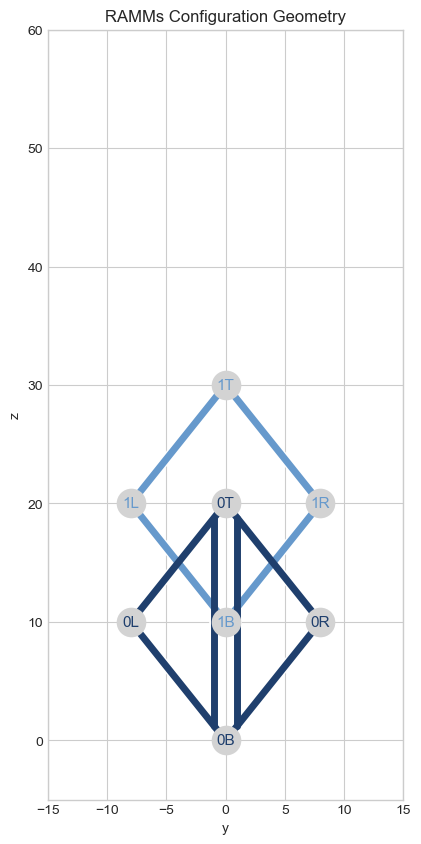

<Axes: title={'center': 'RAMMs Configuration Geometry'}, xlabel='y', ylabel='z'>

In [13]:
plot_geometry(
    two_unit_chain,
    xlim=(-15, 15),
    ylim=(-5, 60)
)

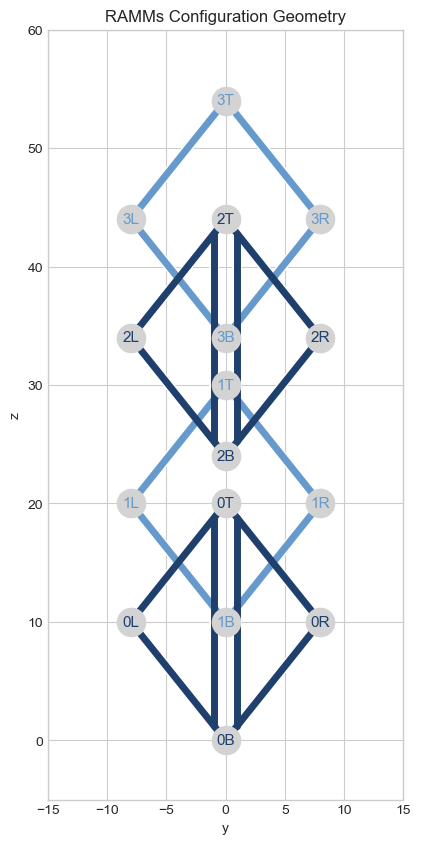

<Axes: title={'center': 'RAMMs Configuration Geometry'}, xlabel='y', ylabel='z'>

In [14]:
plot_geometry(
    four_unit_chain,
    xlim=(-15, 15),
    ylim=(-5, 60)
)

### Test Cascading Rotation

Test cascading rotation on a RAMM Chain with 3+ units.

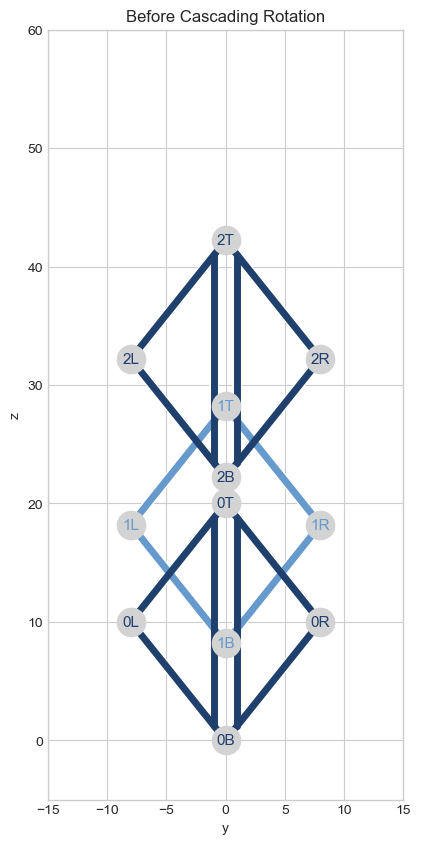

Rotated FREE Unit 1 by -25.000000°.
Translated RAILED Unit 2 and all units above it:
  dy = 8.452365 mm
  dz = -1.873844 mm
Preserved fractional centerline position: s = 0.300000


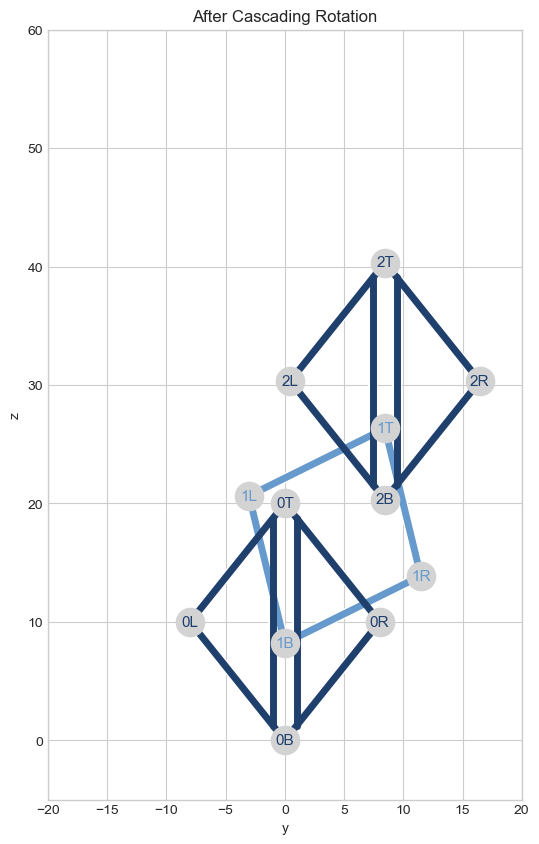

Fractional position after motion: 0.29999999999999993


In [15]:
three_unit_chain = RAMM_Chain.generate(
    n_units=3,
    start_position=(0, 0),
    offsets=[
        (0, 8.2),
        (0, 14),
    ],
    node_diameter=2.0
)

plot_geometry(
    three_unit_chain,
    plot_title="Before Cascading Rotation",
    xlim=(-15, 15),
    ylim=(-5, 60)
)

unit_1_bottom_before = np.asarray(
    three_unit_chain.units[1].bottom_node.coordinates,
    dtype=float
)

unit_2_bottom_before = np.asarray(
    three_unit_chain.units[2].bottom_node.coordinates,
    dtype=float
)

result = three_unit_chain.rotate_with_cascade(
    unit_index=1,
    pivot=three_unit_chain.units[1].bottom_node,
    degrees=-25,
    verbose=True
)

plot_geometry(
    three_unit_chain,
    plot_title="After Cascading Rotation",
    xlim=(-20, 20),
    ylim=(-5, 60)
)

s_after = (
    three_unit_chain
    ._get_fractional_centerline_position(
        free_unit_index=1,
        railed_unit_index=2
    )
)

print("Fractional position after motion:", s_after)

## Gap Distance Methods

### Gap Classes

In [16]:
@dataclass
class GapResult:
    length_mm: float
    projection_coordinate: tuple[float, float]
    node_coordinate: tuple[float, float]

class Gap:
    def __init__(
        self,
        name,
        segment_1,
        node,
        orientation,
        result,
        segment_2=None
    ):
        self.name = name
        self.segment_1 = segment_1
        self.segment_2 = segment_2
        self.node = node
        self.orientation = orientation
        self.result = result

    @property
    def length_mm(self):
        return self.result.length_mm

### Gap Plotting Functions

In [17]:
def plot_gap(chain, gap):
    """
    Plot a RAMM chain and overlay a calculated gap in red.
    """

    plot_title=f"Gap Between Segment {gap.segment_1} and Node {gap.node}"

    _, ax = plt.subplots(figsize=(7, 10))

    # Plot the chain without showing it yet.
    plot_geometry(
        chain=chain,
        ax=ax,
        show=False,
        plot_title=plot_title,
    )

    qy, qz = gap.result.projection_coordinate
    py, pz = gap.result.node_coordinate

    # Draw the gap from closest point Q to node P.
    ax.plot(
        [qy, py],
        [qz, pz],
        color="red",
        linestyle="--",
        linewidth=3,
        zorder=10,
        label=f"g = {gap.length_mm:.3f}",
    )

    # Mark closest point Q.
    ax.scatter(
        qy,
        qz,
        color="red",
        marker="x",
        s=100,
        linewidths=3,
        zorder=11,
    )

    ax.annotate(
        "Q",
        xy=(qy, qz),
        xytext=(6, 6),
        textcoords="offset points",
        color="red",
        fontsize=11,
        zorder=12,
    )

    midpoint_y = (qy + py) / 2
    midpoint_z = (qz + pz) / 2

    ax.annotate(
        f"g = {gap.length_mm:.3f}",
        xy=(midpoint_y, midpoint_z),
        xytext=(6, 6),
        textcoords="offset points",
        color="red",
        fontsize=11,
        zorder=12,
    )

    ax.legend()

    plt.show()

### Segment-Node Distance Functions

#### Main Functions

In [18]:
def get_node_segment_distance(node, segment, orientation):
    """
    Calculate the signed gap between a node and a finite segment.

    A negative gap indicates penetration only when the node's perpendicular
    projection lies on the finite segment. Distances to segment endpoints
    remain nonnegative.
    """

    ay, az = segment.node_1.coordinates
    by, bz = segment.node_2.coordinates
    py, pz = node.coordinates

    # Segment direction: u = B - A
    uy = by - ay
    uz = bz - az

    # Vector from A to node: v = P - A
    vy = py - ay
    vz = pz - az

    u_length_squared = uy**2 + uz**2

    if math.isclose(u_length_squared, 0.0):
        raise InvalidRAMMGeometryError(
            "Cannot calculate a gap from a zero-length segment."
        )

    # Projection onto the infinite supporting line
    raw_t = (vy * uy + vz * uz) / u_length_squared

    # Projection onto the finite segment
    t = max(0.0, min(1.0, raw_t))

    qy = ay + t * uy
    qz = az + t * uz

    unsigned_gap = math.hypot(
        py - qy,
        pz - qz
    )

    orientation = orientation.lower()

    if orientation == "counterclockwise":
        expected_side = 1
    elif orientation == "clockwise":
        expected_side = -1
    else:
        raise ValueError(
            "orientation must be 'clockwise' or 'counterclockwise'"
        )

    # Only use the line-side test when the perpendicular projection
    # actually lies on the finite segment.
    projection_is_on_segment = 0.0 <= raw_t <= 1.0

    if not projection_is_on_segment:
        # The closest point is an endpoint. The side of the infinite
        # supporting line does not indicate penetration.
        signed_gap = unsigned_gap

    else:
        cross_product = uy * vz - uz * vy

        if math.isclose(cross_product, 0.0, abs_tol=1e-12):
            signed_gap = 0.0
        else:
            actual_side = 1 if cross_product > 0 else -1

            signed_gap = (
                unsigned_gap
                if actual_side == expected_side
                else -unsigned_gap
            )

    return GapResult(
        length_mm=signed_gap,
        projection_coordinate=(qy, qz),
        node_coordinate=(py, pz),
    )


def get_node_segment_gap(node, segment, orientation, verbose=False):

    gap_result = get_node_segment_distance(
        node=node,
        segment=segment,
        orientation=orientation,
    )

    gap_name = (
        f"gap_{segment.descriptor}_"
        f"{node.descriptor}"
    )

    gap = Gap(
        name=gap_name,
        segment_1=segment,
        node=node,
        orientation=orientation,
        result=gap_result,
    )

    if verbose:
        if gap.length_mm < 0:
            print(
                f"Invalid configuration\n"
                f"Gap: {gap.length_mm:.6f} mm"
            )

        elif math.isclose(
            gap.length_mm,
            0.0,
            abs_tol=1e-6
        ):
            print("Contact")

        else:
            print(
                f"Segment {segment.descriptor} and "
                f"node {node.descriptor} "
                f"are not in contact.\n"
                f"Gap: {gap.length_mm:.6f} mm"
            )

    return gap

#### Testing Node-Segment Distance Method

In [19]:
RAMMs_unit_1 = 1
# NOTE: [Correct] Orientation is measured from the directed segment A→B toward the node
    # ex. the correct orientation of 1T1R (A = 1T, B = 1R) and node 0T is "clockwise":
        # rotate the segment 1T1R clockwise to get to node 0T
        # segments point from A -> B, and rotate about A

# Top unit segments
segment_1B1L = two_unit_chain.get_segment_by_long_name(RAMMs_unit_1, "bottom -> left")
segment_1T1R = two_unit_chain.get_segment_by_long_name(RAMMs_unit_1, "top -> right")
segment_1R1B = two_unit_chain.get_segment_by_long_name(RAMMs_unit_1, "right -> bottom")
segment_1L1T = two_unit_chain.get_segment_by_long_name(RAMMs_unit_1, "left -> top")

# Unit 0 top node
node_0T = two_unit_chain.units[0].top_node
node_0R = two_unit_chain.units[0].right_node
node_0B = two_unit_chain.units[0].bottom_node
node_0L = two_unit_chain.units[0].left_node

# Evaluate Bottom Unit Top Node and Top Unit Segment Gaps
gap_segment_1B1L_0T = get_node_segment_gap(node_0T, segment_1B1L, "clockwise", verbose=True)
gap_segment_1T1R_0T = get_node_segment_gap(node_0T, segment_1R1B, "clockwise", verbose=True)
gap_segment_1R1B_0T = get_node_segment_gap(node_0T, segment_1B1L, "clockwise", verbose=True)
gap_segment_1L1T_0T = get_node_segment_gap(node_0T, segment_1T1R, "clockwise", verbose=True)

# Evaluate Bottom Unit Bottom Node and Top Unit Segment Gaps
gap_segment_1B1L_0B = get_node_segment_gap(node_0B, segment_1B1L, "counterclockwise", verbose=True)
gap_segment_1R1B_0B = get_node_segment_gap(node_0B, segment_1R1B, "counterclockwise", verbose=True)

# Evaluate bottom unit left and right Nodes compared to respective left and right top unit segments
gap_segment_1B1L_0L = get_node_segment_gap(node_0L, segment_1B1L, "counterclockwise", verbose=True)
gap_segment_1R1B_0R = get_node_segment_gap(node_0R, segment_1R1B, "counterclockwise", verbose=True)

Segment 1B1L and node 0T are not in contact.
Gap: 6.246950 mm
Segment 1R1B and node 0T are not in contact.
Gap: 6.246950 mm
Segment 1B1L and node 0T are not in contact.
Gap: 6.246950 mm
Segment 1T1R and node 0T are not in contact.
Gap: 6.246950 mm
Segment 1B1L and node 0B are not in contact.
Gap: 10.000000 mm
Segment 1R1B and node 0B are not in contact.
Gap: 10.000000 mm
Segment 1B1L and node 0L are not in contact.
Gap: 6.246950 mm
Segment 1R1B and node 0R are not in contact.
Gap: 6.246950 mm


##### Plot chain with gap overlay for each measurement

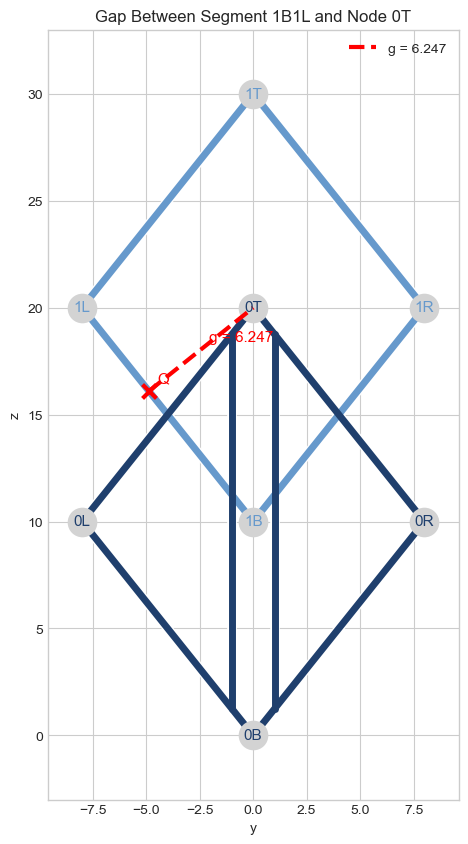

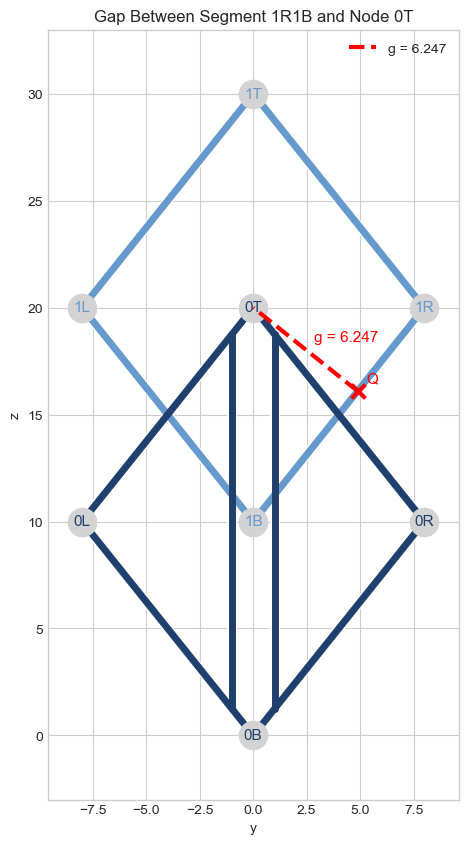

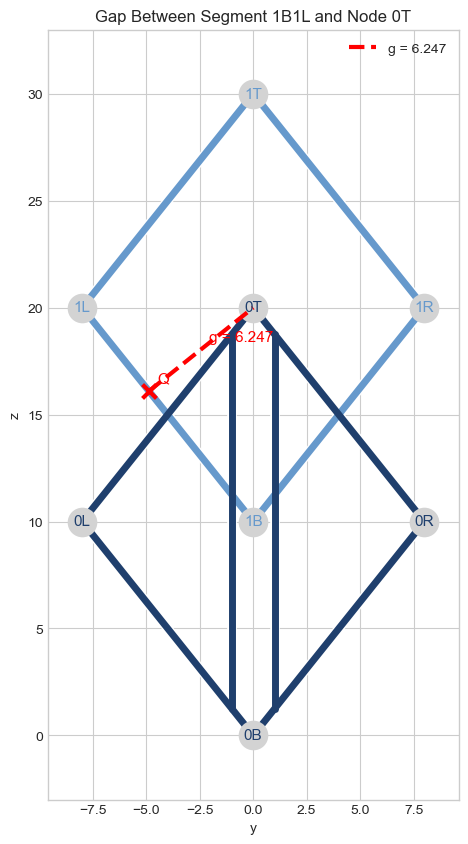

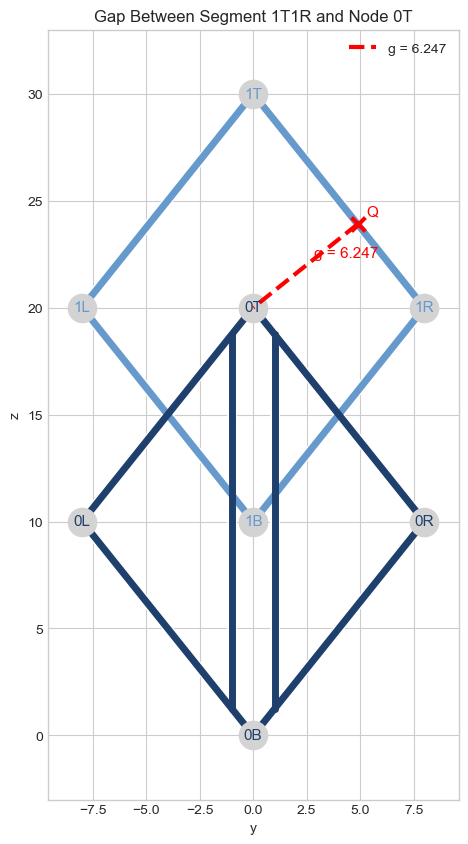

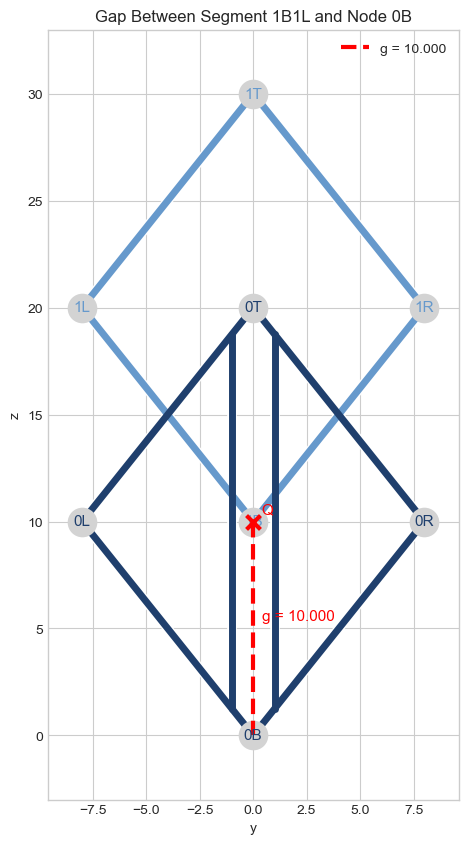

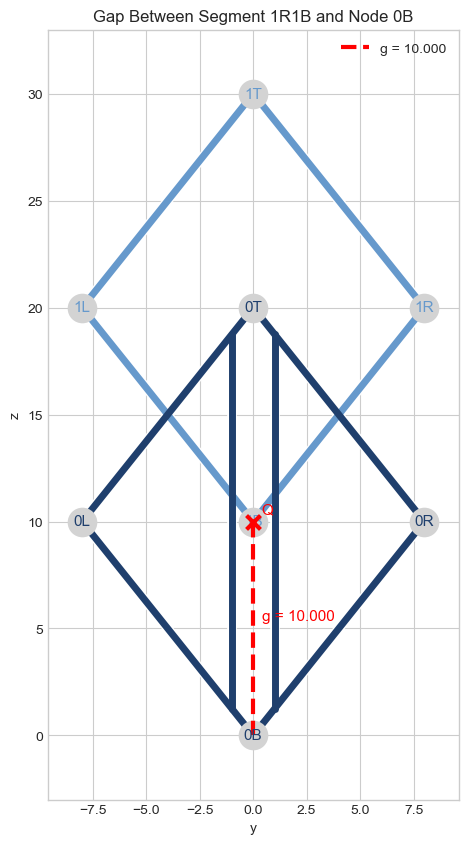

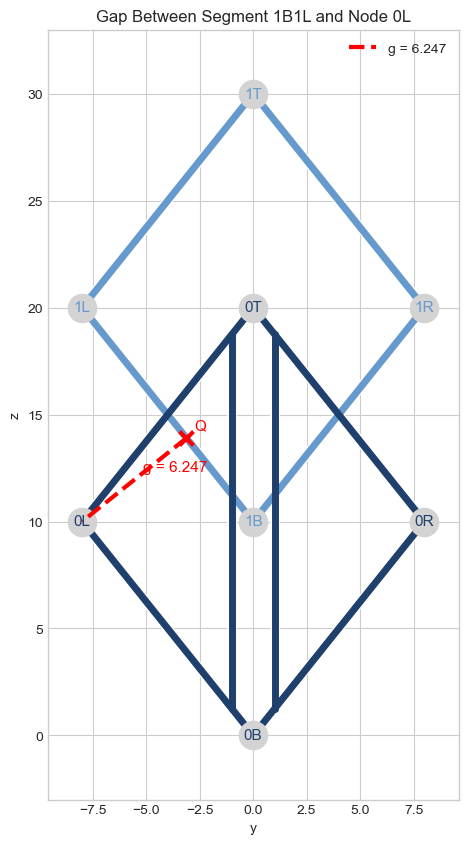

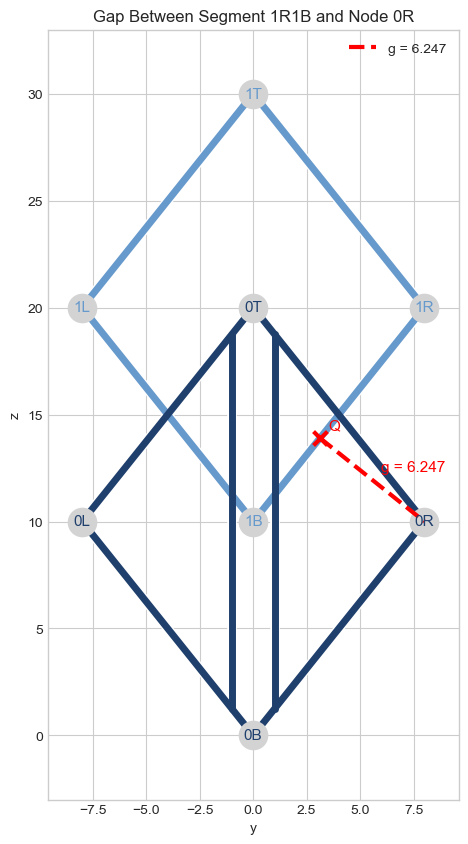

In [20]:
plot_gap(two_unit_chain, gap_segment_1B1L_0T)
plot_gap(two_unit_chain, gap_segment_1T1R_0T)
plot_gap(two_unit_chain, gap_segment_1R1B_0T)
plot_gap(two_unit_chain, gap_segment_1L1T_0T)
plot_gap(two_unit_chain, gap_segment_1B1L_0B)
plot_gap(two_unit_chain, gap_segment_1R1B_0B)
plot_gap(two_unit_chain, gap_segment_1B1L_0L)
plot_gap(two_unit_chain, gap_segment_1R1B_0R)

## Extending the Jamming Analysis to a 3-Unit Chain

#### Basic Interaction Types

A 2-unit chain has only one type/class of contact/interaction:

- **RAILED–FREE** (adjacent units–bottom unit node(s) compared to top-unit segment(s))

A 3-unit chain introduces another class of interactions (and can reverse the first one):

- **RAILED–SKIP–RAILED** (nonadjacent units)
- **FREE–RAILED** (adjacent units–bottom unit segment(s) compared to top-unit node(s))

---

#### Degrees of Freedom

A 2-unit chain contains one FREE unit with two configuration variables:

- rotation
- vertical translation

Consequently, two independent contact constraints are sufficient to fully jam the chain.

A 3-unit chain contains two FREE units with four configuration variables:

- Unit 1: rotation, vertical translation
- Unit 2: rotation, vertical translation

This suggests that four independent contact constraints may be required to completely jam the structure.

> <span style="color:#1E90FF"><strong>📝 Note</strong></span>  
> This is currently a working hypothesis and should ultimately be verified using the Jacobian/null-space formulation.

---

#### Other Interactions Worth Considering

##### RAILED–SKIP–RAILED Interactions

RAILED–SKIP–RAILED interactions require detecting segment–segment contact.

A segment–segment contact alone is not expected to jam the mechanism because the segments may still slide relative to one another.

Instead, segment–segment contact will likely need to occur simultaneously with an additional node–segment contact involving the neighboring unit.

##### FREE–SKIP–FREE Interactions

FREE–SKIP–FREE interactions appear to produce only point–point contacts and are not currently expected to contribute useful constraints toward jamming.

These contacts may still be useful for identifying geometric limits or infeasible configurations.

---

#### Working Hypothesis

A fully jammed 3-unit chain may require

- two bottom-adjacent-unit contacts (RAILED–FREE),
- one skip-level segment–segment contact (RAILED-SKIP-RAILED), and
- one top-adjacent-unit node–segment contact involving Unit 2 (FREE-RAILED)

This hypothesis should be validated using the configuration-dependent Jacobian.

---

#### Proposed Workflow

1. Determine the maximum-angle contact between Units 0 and 1.
2. Rotate Unit 2 away from the penetrating direction.
3. Rotate Unit 2 until the skip-level segments become parallel.
4. Translate Unit 2 until the skip-level segments contact.
5. If necessary, continue translating until the final node–segment contact occurs.

### Segment-Segment Distance Functions

In [21]:
# helper to return nodes top to bottom
def get_nodes_top_to_bottom(segment):
    y_1, z_1 = segment.node_1.coordinates
    y_2, z_2 = segment.node_2.coordinates
    
    if z_1 > z_2:
        print(f"For segment {segment}, node 1 (appears first clockwise) is above node 2")
        return (y_1, z_1), (y_2, z_2)
    else:
        print(f"For segment {segment}, node 2 (appears first clockwise) is above node 1")
        return (y_2, z_2), (y_1, z_1)

    return


def get_nodes_left_to_right(segment, tolerance=1e-9):
    y1, _ = segment.node_1.coordinates
    y2, _ = segment.node_2.coordinates

    if math.isclose(y1, y2, abs_tol=tolerance):
        raise ValueError(
            f"Segment {segment} is vertical, so left/right ordering is undefined."
        )

    if y1 < y2:
        return segment.node_1, segment.node_2

    return segment.node_2, segment.node_1


def parallel_segments_touch(A, B, C, D, tolerance=1e-6):
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    C = np.asarray(C, dtype=float)
    D = np.asarray(D, dtype=float)

    u = B - A
    length = np.linalg.norm(u)

    if length <= tolerance:
        raise ValueError("Segment A-B has zero length.")

    tangent = u / length

    # Perpendicular distance between the supporting lines
    v = C - A
    perpendicular_distance = abs(
        u[0] * v[1] - u[1] * v[0]
    ) / length

    if perpendicular_distance > tolerance:
        return False

    # Project all endpoints onto segment 1's tangent direction
    a_proj = np.dot(A, tangent)
    b_proj = np.dot(B, tangent)
    c_proj = np.dot(C, tangent)
    d_proj = np.dot(D, tangent)

    segment_1_min, segment_1_max = sorted((a_proj, b_proj))
    segment_2_min, segment_2_max = sorted((c_proj, d_proj))

    # Amount by which the projected intervals overlap
    overlap = min(segment_1_max, segment_2_max) - max(
        segment_1_min,
        segment_2_min
    )

    return overlap >= -tolerance


def cross_2d(a, b):
    return a[0] * b[1] - a[1] * b[0]


def get_segment_segment_distance(
    bottom_unit_segment: RAMM_Strut,
    top_unit_segment: RAMM_Strut,
    tolerance=1e-6
):
    A = np.asarray(
        bottom_unit_segment.node_1.coordinates,
        dtype=float
    )
    B = np.asarray(
        bottom_unit_segment.node_2.coordinates,
        dtype=float
    )
    C = np.asarray(
        top_unit_segment.node_1.coordinates,
        dtype=float
    )
    D = np.asarray(
        top_unit_segment.node_2.coordinates,
        dtype=float
    )

    u = B - A
    v = D - C

    length_u = np.linalg.norm(u)
    length_v = np.linalg.norm(v)

    if length_u <= tolerance or length_v <= tolerance:
        raise ValueError("Cannot evaluate a zero-length segment.")

    # Parallel when the direction-vector cross product is approximately zero.
    parallel = math.isclose(
        cross_2d(u, v),
        0.0,
        abs_tol=tolerance
    )

    print(f"Segments are parallel: {parallel}")

    if not parallel:
        return {
            "parallel": False,
            "perpendicular_distance": None,
            "overlap": None,
            "touching": False
        }

    # Distance between the two parallel supporting lines.
    perpendicular_distance = abs(
        cross_2d(u, C - A)
    ) / length_u

    # Project both segments onto the unit tangent of segment A-B.
    tangent = u / length_u

    a_proj = np.dot(A, tangent)
    b_proj = np.dot(B, tangent)
    c_proj = np.dot(C, tangent)
    d_proj = np.dot(D, tangent)

    bottom_min, bottom_max = sorted((a_proj, b_proj))
    top_min, top_max = sorted((c_proj, d_proj))

    overlap = min(bottom_max, top_max) - max(
        bottom_min,
        top_min
    )

    touching = (
        perpendicular_distance <= tolerance
        and overlap >= -tolerance
    )

    print(
        f"Perpendicular distance: "
        f"{perpendicular_distance:.6f}"
    )
    print(f"Projected overlap: {overlap:.6f}")
    print(f"Segments are touching: {touching}")

    return {
        "parallel": parallel,
        "perpendicular_distance": perpendicular_distance,
        "overlap": overlap,
        "touching": touching
    }

In [22]:
get_segment_segment_distance(segment_1B1L, segment_1R1B)

Segments are parallel: False


{'parallel': False,
 'perpendicular_distance': None,
 'overlap': None,
 'touching': False}

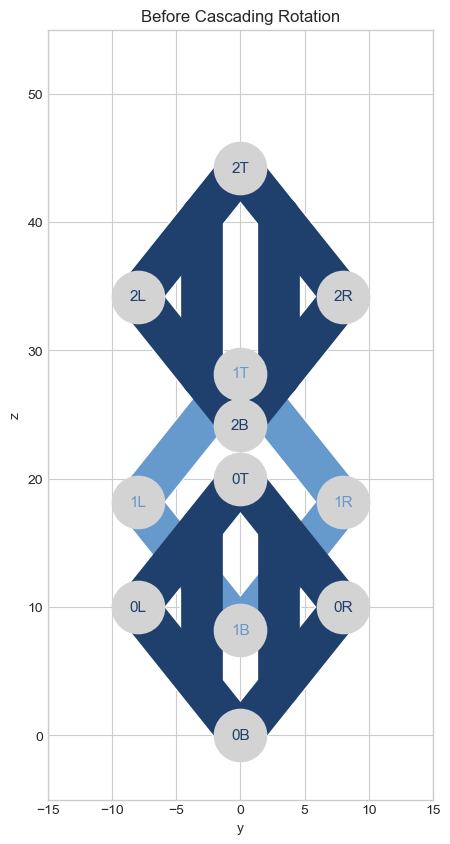

Rotated FREE Unit 1 by -28.390000°.
Translated RAILED Unit 2 and all units above it:
  dy = 9.509413 mm
  dz = -2.405369 mm
Preserved fractional centerline position: s = 0.200000


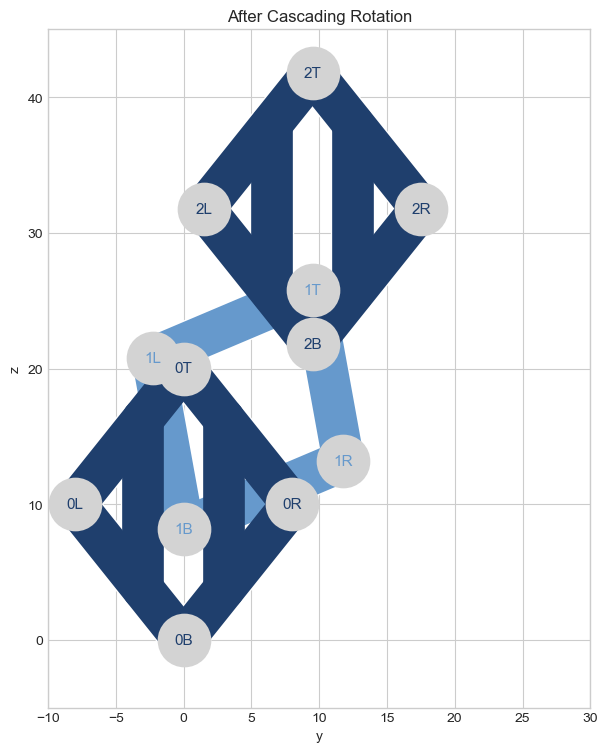

Translating Unit 2: dy = 0.000000, dz = -8.750000


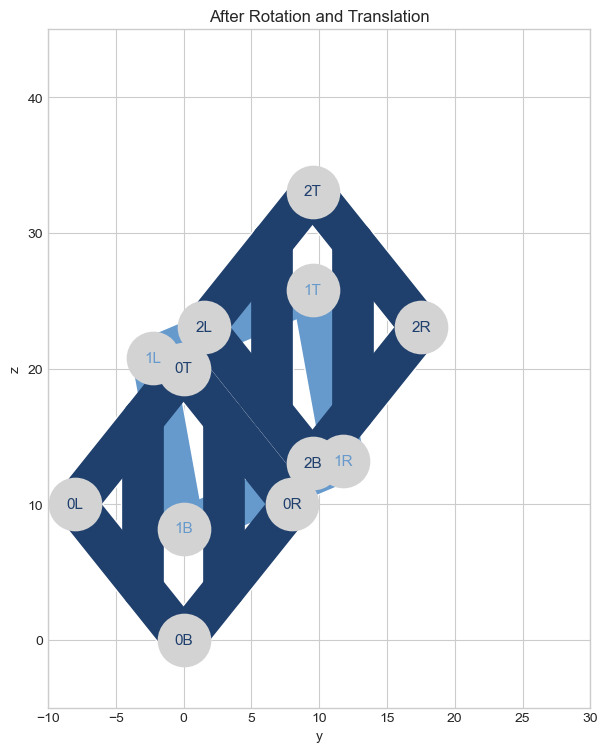

<Axes: title={'center': 'After Rotation and Translation'}, xlabel='y', ylabel='z'>

In [23]:
three_unit_chain = RAMM_Chain.generate(
    n_units=3,
    start_position=(0, 0),
    offsets=[
        (0, 8.2),
        (0, 16),
    ],
    node_diameter=6.0
)

NODE_DIAMETER_PLOT = 1200
SEG_LINE_WIDTH = 30

plot_geometry(
    three_unit_chain,
    plot_title="Before Cascading Rotation",
    xlim=(-15, 15),
    ylim=(-5, 55),
    node_diameter=NODE_DIAMETER_PLOT,
    segment_line_width=SEG_LINE_WIDTH
)

_ = three_unit_chain.rotate_with_cascade(
    unit_index=1,
    pivot=three_unit_chain.units[1].bottom_node,
    degrees=-28.39,
    verbose=True
)

plot_geometry(
    three_unit_chain,
    plot_title="After Cascading Rotation",
    xlim=(-10, 30),
    ylim=(-5, 45),
    node_diameter=NODE_DIAMETER_PLOT,
    segment_line_width=SEG_LINE_WIDTH
)

three_unit_chain.translate(2, dy=0, dz=-8.75, verbose=True)

plot_geometry(
    three_unit_chain,
    plot_title="After Rotation and Translation",
    xlim=(-10, 30),
    ylim=(-5, 45),
    node_diameter=NODE_DIAMETER_PLOT,
    segment_line_width=SEG_LINE_WIDTH
)

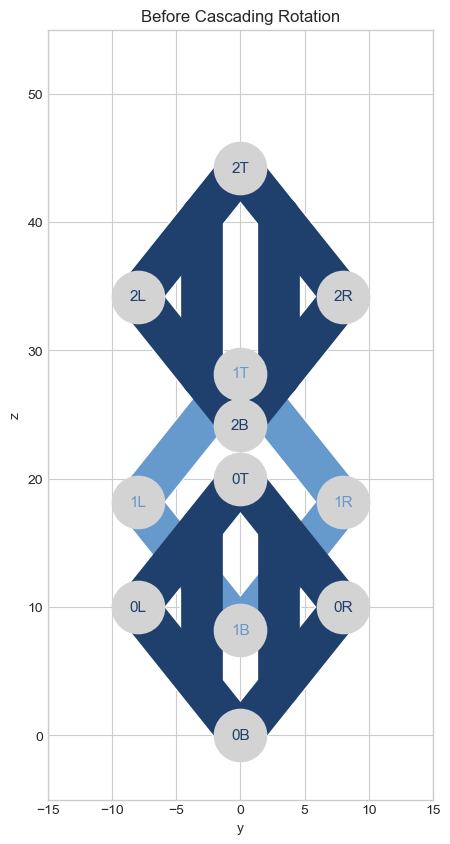

Rotated FREE Unit 1 by 28.390000°.
Translated RAILED Unit 2 and all units above it:
  dy = -9.509413 mm
  dz = -2.405369 mm
Preserved fractional centerline position: s = 0.200000


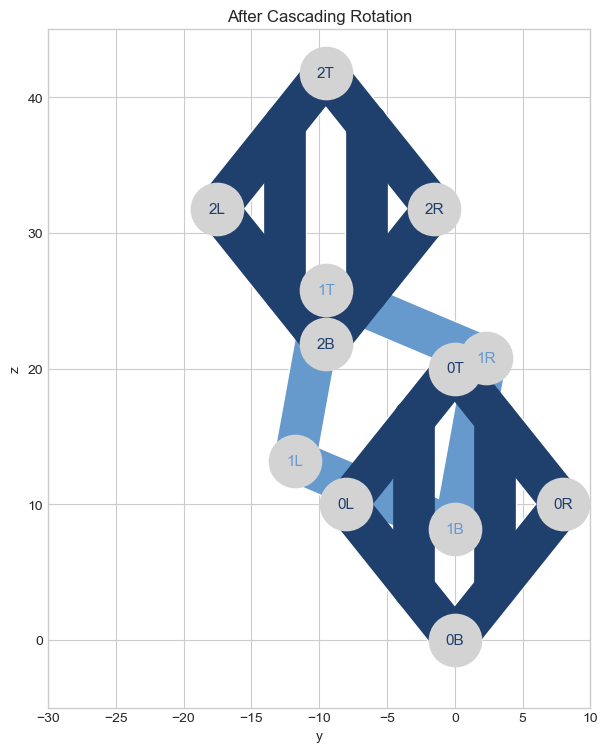

Translating Unit 2: dy = 0.000000, dz = -8.750000


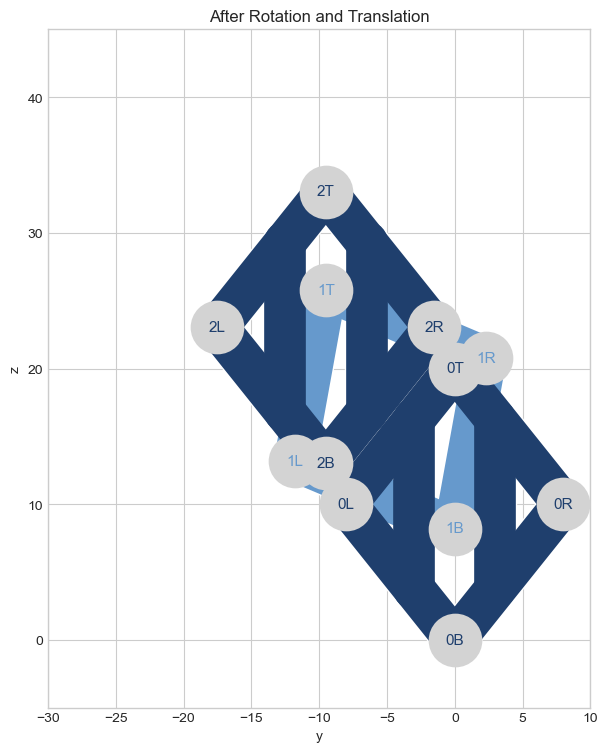

<Axes: title={'center': 'After Rotation and Translation'}, xlabel='y', ylabel='z'>

In [24]:
three_unit_chain = RAMM_Chain.generate(
    n_units=3,
    start_position=(0, 0),
    offsets=[
        (0, 8.2),
        (0, 16),
    ],
    node_diameter=6.0
)

NODE_DIAMETER_PLOT = 1200
SEG_LINE_WIDTH = 30

plot_geometry(
    three_unit_chain,
    plot_title="Before Cascading Rotation",
    xlim=(-15, 15),
    ylim=(-5, 55),
    node_diameter=NODE_DIAMETER_PLOT,
    segment_line_width=SEG_LINE_WIDTH
)

_ = three_unit_chain.rotate_with_cascade(
    unit_index=1,
    pivot=three_unit_chain.units[1].bottom_node,
    degrees=28.39,
    verbose=True
)

plot_geometry(
    three_unit_chain,
    plot_title="After Cascading Rotation",
    xlim=(-30, 10),
    ylim=(-5, 45),
    node_diameter=NODE_DIAMETER_PLOT,
    segment_line_width=SEG_LINE_WIDTH
)

three_unit_chain.translate(2, dy=0, dz=-8.75, verbose=True)

plot_geometry(
    three_unit_chain,
    plot_title="After Rotation and Translation",
    xlim=(-30, 10),
    ylim=(-5, 45),
    node_diameter=NODE_DIAMETER_PLOT,
    segment_line_width=SEG_LINE_WIDTH
)

In [25]:
three_unit_chain_struts = three_unit_chain.get_struts_bottom_to_top_clockwise()

for strut in three_unit_chain_struts:
    print(strut)

0T0R
0R0B
0B0L
0L0T
1T1R
1R1B
1B1L
1L1T
2T2R
2R2B
2B2L
2L2T


In [26]:
segment_0T0R = three_unit_chain.get_segment_by_descriptor("0T0R")
segment_2B2L = three_unit_chain.get_segment_by_descriptor("2B2L")
get_segment_segment_distance(segment_0T0R, segment_2B2L)

Segments are parallel: True
Perpendicular distance: 11.770589
Projected overlap: -0.509253
Segments are touching: False


{'parallel': True,
 'perpendicular_distance': 11.770588684504022,
 'overlap': -0.5092531347886222,
 'touching': False}

In [27]:
pivot_1T = three_unit_chain.get_node_by_descriptor("1T")
pivot_1T.descriptor

'1T'

### Test Segment-Segment Gap Finding Method

> <span style="color:#FF8C00"><strong>🚧 TODO</strong></span>  
> Test detection of overlapping segments in a 3-unit chain.

> <span style="color:#FF8C00"><strong>🚧 TODO</strong></span>  
> Generate 3-unit chain for testing (and plot it!)

> <span style="color:#FF8C00"><strong>🚧 TODO</strong></span>  
> Determine the rotation angle required for Unit 2's bottom strut becomes parallel to Unit 0's top strut.

> <span style="color:#1E90FF"><strong>📝 Note</strong></span>  
> Once this configuration is reached, test the new segment–segment contact detection functions.

## Symbolic Gaps

#### Symbolic Gap Classes and Functions

In [28]:
@dataclass
class SymbolicGap:
    A: sp.Matrix
    B: sp.Matrix
    P: sp.Matrix
    u: sp.Matrix
    v: sp.Matrix
    t: sp.Expr
    Q: sp.Matrix
    gap_vector: sp.Matrix
    gap_magnitude: sp.Expr
    signed_gap: sp.Expr

#### General Symbolic Gap Function

In [29]:
# NOTE: We dont actually need this; just a check.
# The more useful method is working below
def get_symbolic_gap_general():

    Ay, Az = sp.symbols("Ay Az", real=True)
    By, Bz = sp.symbols("By Bz", real=True)
    Py, Pz = sp.symbols("Py Pz", real=True)

    A = sp.Matrix([Ay, Az])
    B = sp.Matrix([By, Bz])
    P = sp.Matrix([Py, Pz])

    u = B - A
    v = P - A

    u_squared_length = u.dot(u)
    t = v.dot(u) / u_squared_length

    Q = A + t * u
    gap_vector = P - Q
    gap_magnitude = gap_vector.norm()

    symbolic_gap = SymbolicGap(
        A=A,
        B=B,
        P=P,
        u=u,
        v=v,
        t=t,
        Q=Q,
        gap_vector=gap_vector,
        gap_magnitude=gap_magnitude,
        signed_gap=None
    )

    return symbolic_gap

In [30]:
symbolic_gap = get_symbolic_gap_general()
print("Symbolic gap A:")
display(symbolic_gap.A)

print("Symbolic gap t:")
display(symbolic_gap.t)

print("Symbolic gap vector:")
display(symbolic_gap.gap_vector)

print("Symbolic gap magnitude:")
display(symbolic_gap.gap_magnitude)

Symbolic gap A:


Matrix([
[Ay],
[Az]])

Symbolic gap t:


((-Ay + By)*(-Ay + Py) + (-Az + Bz)*(-Az + Pz))/((-Ay + By)**2 + (-Az + Bz)**2)

Symbolic gap vector:


Matrix([
[-Ay + Py - (-Ay + By)*((-Ay + By)*(-Ay + Py) + (-Az + Bz)*(-Az + Pz))/((-Ay + By)**2 + (-Az + Bz)**2)],
[-Az + Pz - (-Az + Bz)*((-Ay + By)*(-Ay + Py) + (-Az + Bz)*(-Az + Pz))/((-Ay + By)**2 + (-Az + Bz)**2)]])

Symbolic gap magnitude:


sqrt(Abs(-Ay + Py - (-Ay + By)*((-Ay + By)*(-Ay + Py) + (-Az + Bz)*(-Az + Pz))/((-Ay + By)**2 + (-Az + Bz)**2))**2 + Abs(-Az + Pz - (-Az + Bz)*((-Ay + By)*(-Ay + Py) + (-Az + Bz)*(-Az + Pz))/((-Ay + By)**2 + (-Az + Bz)**2))**2)

#### Specific Symbolic Gap Function for a Node-Segment Gaps

In [31]:
def get_node_segment_symbolic_gap(node, segment, orientation):

    left_y, left_z = sp.symbols(
        f"A_{segment.node_1}_y "
        f"A_{segment.node_1}_z",
        real=True
    )

    right_y, right_z = sp.symbols(
        f"B_{segment.node_2}_y "
        f"B_{segment.node_2}_z",
        real=True
    )

    node_y, node_z = sp.symbols(
        f"P_{node}_y "
        f"P_{node}_z",
        real=True
    )

    A = sp.Matrix([left_y, left_z])
    B = sp.Matrix([right_y, right_z])
    P = sp.Matrix([node_y, node_z])

    u = B - A
    v = P - A

    u_squared_length = u.dot(u)
    t = v.dot(u) / u_squared_length

    Q = A + t * u
    gap_vector = P - Q
    gap_magnitude = gap_vector.norm()

    segment_length = sp.sqrt(u.dot(u))

    if orientation == "counterclockwise":
        normal = sp.Matrix([-u[1], u[0]]) / segment_length
    elif orientation == "clockwise":
        normal = sp.Matrix([u[1], -u[0]]) / segment_length
    else:
        raise ValueError(
            "orientation must be 'clockwise' or 'counterclockwise'"
        )

    signed_gap = sp.simplify(normal.dot(v))

    return SymbolicGap(
        A=A,
        B=B,
        P=P,
        u=u,
        v=v,
        t=t,
        Q=Q,
        gap_vector=gap_vector,
        gap_magnitude=gap_magnitude,
        signed_gap=signed_gap
    )

In [32]:
symbolic_gap_1B1L_0T = get_node_segment_symbolic_gap(node_0T, segment_1B1L, "clockwise")
display(symbolic_gap_1B1L_0T.gap_magnitude)

sqrt(Abs(-A_1B_y + P_0T_y - (-A_1B_y + B_1L_y)*((-A_1B_y + B_1L_y)*(-A_1B_y + P_0T_y) + (-A_1B_z + B_1L_z)*(-A_1B_z + P_0T_z))/((-A_1B_y + B_1L_y)**2 + (-A_1B_z + B_1L_z)**2))**2 + Abs(-A_1B_z + P_0T_z - (-A_1B_z + B_1L_z)*((-A_1B_y + B_1L_y)*(-A_1B_y + P_0T_y) + (-A_1B_z + B_1L_z)*(-A_1B_z + P_0T_z))/((-A_1B_y + B_1L_y)**2 + (-A_1B_z + B_1L_z)**2))**2)

In [33]:
# TODO: you may not need this; you may need to rewrite it IDK
# DONT USE FOR JACOBIAN (USE FIRST ONE if we eval and node is on the correct side of gap)
def get_symbolic_gap_finite_segment(segment, node):

    # Create symbolic node positions.
    left_y, left_z = sp.symbols(
        f"A_{segment.node_1}_y "
        f"A_{segment.node_1}_z",
        real=True
    )

    right_y, right_z = sp.symbols(
        f"B_{segment.node_2}_y "
        f"B_{segment.node_2}_z",
        real=True
    )

    node_y, node_z = sp.symbols(
        f"P_{node}_y "
        f"P_{node}_z",
        real=True
    )

    A = sp.Matrix([left_y, left_z])
    B = sp.Matrix([right_y, right_z])
    P = sp.Matrix([node_y, node_z])

    u = B - A
    v = P - A

    u_squared_length = u.dot(u)

    if sp.simplify(u_squared_length) == 0:
        raise ValueError(
            "Cannot define a gap from a zero-length segment."
        )

    t = v.dot(u) / u_squared_length

    # Projection onto the infinite line.
    Q_line = A + t * u

    line_gap_vector = P - Q_line
    left_gap_vector = P - A
    right_gap_vector = P - B

    line_distance = line_gap_vector.norm()
    left_distance = left_gap_vector.norm()
    right_distance = right_gap_vector.norm()

    # Closest point on the finite segment.
    Q = sp.Piecewise(
        (A, t < 0),
        (B, t > 1),
        (Q_line, True)
    )

    gap_vector = sp.Piecewise(
        (left_gap_vector, t < 0),
        (right_gap_vector, t > 1),
        (line_gap_vector, True)
    )

    gap_magnitude = sp.Piecewise(
        (left_distance, t < 0),
        (right_distance, t > 1),
        (line_distance, True)
    )

    return SymbolicGap(
        A=A,
        B=B,
        P=P,
        u=u,
        v=v,
        t=t,
        Q=Q,
        gap_vector=gap_vector,
        gap_magnitude=gap_magnitude,
    )

#### Get Active Node-Segment Gaps for a Chain in a Specific Config

In [34]:
def get_candidate_gaps(chain):
    gaps = []

    for lower_unit in range(0, len(chain.units) - 1, 2):
        upper_unit = lower_unit + 1

        segment_BL = chain.get_segment_by_descriptor(
            f"{upper_unit}B{upper_unit}L"
        )
        segment_TR = chain.get_segment_by_descriptor(
            f"{upper_unit}T{upper_unit}R"
        )
        segment_RB = chain.get_segment_by_descriptor(
            f"{upper_unit}R{upper_unit}B"
        )
        segment_LT = chain.get_segment_by_descriptor(
            f"{upper_unit}L{upper_unit}T"
        )

        node_T = chain.get_node_by_descriptor(f"{lower_unit}T")
        node_R = chain.get_node_by_descriptor(f"{lower_unit}R")
        node_B = chain.get_node_by_descriptor(f"{lower_unit}B")
        node_L = chain.get_node_by_descriptor(f"{lower_unit}L")

        gaps.extend([
            get_node_segment_gap(node_T, segment_BL, "clockwise"),
            get_node_segment_gap(node_T, segment_TR, "clockwise"),
            get_node_segment_gap(node_T, segment_RB, "clockwise"),
            get_node_segment_gap(node_T, segment_LT, "clockwise"),

            get_node_segment_gap(node_B, segment_BL, "counterclockwise"),
            get_node_segment_gap(node_B, segment_RB, "counterclockwise"),

            get_node_segment_gap(node_L, segment_BL, "counterclockwise"),
            get_node_segment_gap(node_R, segment_RB, "counterclockwise"),
        ])

    return gaps

def get_active_gap_vector(candidate_gaps, tolerance=1e-6, verbose=False):
    active_gap_expressions = []

    for candidate in candidate_gaps:
        gap_length_mm = candidate.result.length_mm

        if verbose:
            if gap_length_mm < -tolerance:
                print(
                    f"❌ PENETRATING! {candidate.segment_1} and {candidate.node}\n"
                    f"Gap: {gap_length_mm:.6f} mm"
                )

            elif gap_length_mm <= tolerance:
                print(
                    f"✅ CONTACT: {candidate.segment_1} and {candidate.node}\n"
                    f"Gap: {gap_length_mm:.6f} mm"
                )

            else:
                print(
                    f"Gap between {candidate.segment_1} and {candidate.node} is greater than 0.\n"
                    f"Gap: {gap_length_mm:.6f} mm"
                )

        if math.isclose(gap_length_mm, 0.0, abs_tol=tolerance):
            symbolic_gap = get_node_segment_symbolic_gap(
                candidate.node,
                candidate.segment_1,
                candidate.orientation
            )
            active_gap_expressions.append(symbolic_gap.signed_gap)
    
    active_gap_vector = sp.Matrix(active_gap_expressions)

    if verbose:
        display(active_gap_vector)

    return active_gap_vector

## Find Max Angle and Vertical Limit (Contact Points) Functions

> <span style="color:red"><strong>🚧 TODO</strong></span>  
> Find the maximum allowable rotation (contact points) so we can test `get_active_gap_vector()` on a chain that should be in contact.

Then move on to the Jacobian.

### Test Unit Rotation Methods and Symbolic Gap Function Finding for Two-Unit Chain

#### Test RAMM Unit Rotation Method
Rotate and translate top RAMM unit (use method in RAMM_Unit class)

Rotating unit 1 around 1B by 38.7 degrees...


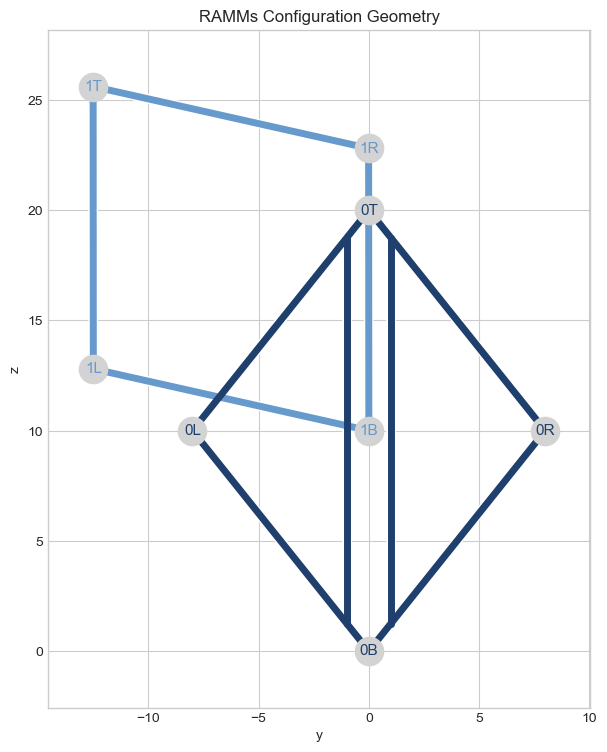

<Axes: title={'center': 'RAMMs Configuration Geometry'}, xlabel='y', ylabel='z'>

In [35]:
two_unit_chain.reset() # resets chain to vertical offset (z) or 10mm

unit_1B = two_unit_chain.units[1].bottom_node

two_unit_chain.rotate(
    unit_index=1,
    pivot=unit_1B,
    degrees=38.7
)

plot_geometry(two_unit_chain)

#### Test Getting Single Contact Symbolic Active Gap Vector

> <span style="color:#DAA520"><strong>⚠️ Warning</strong></span>  
> The `get_candidate_gaps()` and `get_active_gap_vector()` are defined below...may want to move this later

In [36]:
candidate_gaps = get_candidate_gaps(two_unit_chain)
active_gap_vector = get_active_gap_vector(candidate_gaps, tolerance=0.01, verbose=True)

Gap between 1B1L and 0T is greater than 0.
Gap: 9.757635 mm
Gap between 1T1R and 0T is greater than 0.
Gap: 2.806260 mm
✅ CONTACT: 1R1B and 0T
Gap: -0.007015 mm
Gap between 1L1T and 0T is greater than 0.
Gap: 12.500916 mm
Gap between 1B1L and 0B is greater than 0.
Gap: 10.000000 mm
Gap between 1R1B and 0B is greater than 0.
Gap: 10.000000 mm
Gap between 1B1L and 0L is greater than 0.
Gap: 1.750622 mm
Gap between 1R1B and 0R is greater than 0.
Gap: 8.000000 mm


Matrix([[(-(A_1R_y - B_1B_y)*(A_1R_z - P_0T_z) + (A_1R_y - P_0T_y)*(A_1R_z - B_1B_z))/sqrt((A_1R_y - B_1B_y)**2 + (A_1R_z - B_1B_z)**2)]])

### Find Max/Min Angle and Vertical Limits for Two-Unit Chain

#### Two-Unit Chain Max Rotation Finder Method Helpers

In [37]:
def set_two_unit_configuration(
    chain,
    theta_deg,
    z_shift,
    default_offset=10
):
    """
    Recreate the old transform_top_unit_from_reference():

    - reset to the default configuration
    - rotate unit 1 around node 1B
    - translate the entire unit vertically by z_shift
    """
    chain.reset(offset=default_offset)

    unit_1 = chain.units[1]
    pivot = unit_1.bottom_node

    unit_1.transform(
        point=pivot,
        degrees=theta_deg
    )

    unit_1.translate(
        dy=0.0,
        dz=z_shift
    )


def get_right_limit_gaps(chain):
    """
    Maximum-right-rotation contacts from the old notebook:

    1. segment 1R1B contacts node 0R
    2. segment 1B1L contacts node 0T
    """
    segment_1R1B = chain.get_segment_by_descriptor("1R1B")
    segment_1B1L = chain.get_segment_by_descriptor("1B1L")

    node_0R = chain.get_node_by_descriptor("0R")
    node_0T = chain.get_node_by_descriptor("0T")

    gap_right = get_node_segment_gap(
        node=node_0R,
        segment=segment_1R1B,
        orientation="counterclockwise"
    )

    gap_top = get_node_segment_gap(
        node=node_0T,
        segment=segment_1B1L,
        orientation="clockwise"
    )

    return gap_right, gap_top




In [38]:
def get_reference_side(
    chain,
    node_descriptor,
    segment_descriptor,
    orientation,
    default_offset=10
):
    """
    Return +1 or -1 so that the gap is positive on the valid side
    occupied in the default configuration.
    """
    set_two_unit_configuration(
        chain,
        theta_deg=0.0,
        z_shift=0.0,
        default_offset=default_offset
    )

    node = chain.get_node_by_descriptor(node_descriptor)
    segment = chain.get_segment_by_descriptor(segment_descriptor)

    gap = get_node_segment_gap(
        node,
        segment,
        orientation
    ).result.length_mm

    if math.isclose(gap, 0.0, abs_tol=1e-12):
        raise ValueError(
            f"Cannot determine reference side for "
            f"{segment_descriptor} and {node_descriptor}: "
            "the default gap is zero."
        )

    return 1.0 if gap > 0 else -1.0

#### Find Max/Min Rotation For 2-Unit Chain Before Contact Methods

In [39]:
def find_right_max_rotation(
    chain,
    theta_guess=-38.6,
    z_guess=-1.8,
    theta_bounds=(-60.0, 0.0),
    z_bounds=(-8.0, 5.0),
    default_offset=10,
    contact_offset=0.0,
    contact_tolerance=1e-6,
    verbose=True
):
    """
    Find the maximum-right-rotation double-contact configuration.

    Target contacts:
        segment 1R1B with node 0R
        segment 1B1L with node 0T

    Parameters
    ----------
    contact_offset : float, optional
        Required centerline distance at physical contact.

        For zero-thickness geometry:
            contact_offset = 0

        For a circular node and finite-width strut:
            contact_offset = node_radius + strut_half_width
    """

    if contact_offset < 0:
        raise ValueError("contact_offset must be nonnegative.")

    # Determine which side of each segment is valid in the
    # default, nonpenetrating configuration.
    right_side = get_reference_side(
        chain=chain,
        node_descriptor="0R",
        segment_descriptor="1R1B",
        orientation="counterclockwise",
        default_offset=default_offset
    )

    top_side = get_reference_side(
        chain=chain,
        node_descriptor="0T",
        segment_descriptor="1B1L",
        orientation="clockwise",
        default_offset=default_offset
    )

    def evaluate_target_gaps(theta_deg, z_shift):
        set_two_unit_configuration(
            chain=chain,
            theta_deg=theta_deg,
            z_shift=z_shift,
            default_offset=default_offset
        )

        segment_RB = chain.get_segment_by_descriptor("1R1B")
        segment_BL = chain.get_segment_by_descriptor("1B1L")

        node_0R = chain.get_node_by_descriptor("0R")
        node_0T = chain.get_node_by_descriptor("0T")

        gap_right = get_node_segment_gap(
            node_0R,
            segment_RB,
            "counterclockwise"
        )

        gap_top = get_node_segment_gap(
            node_0T,
            segment_BL,
            "clockwise"
        )

        return (
            gap_right.result.length_mm,
            gap_top.result.length_mm
        )

    def residuals(x):
        theta_deg, z_shift = x

        signed_gap_right, signed_gap_top = evaluate_target_gaps(
            theta_deg,
            z_shift
        )

        # Reorient each signed gap so it is positive on the
        # valid side of the segment.
        separation_right = right_side * signed_gap_right
        separation_top = top_side * signed_gap_top

        # Physical contact occurs when:
        # oriented centerline separation = contact_offset
        clearance_right = separation_right - contact_offset
        clearance_top = separation_top - contact_offset

        return np.array([
            clearance_right,
            clearance_top
        ])

    solution = least_squares(
        residuals,
        x0=np.array([theta_guess, z_guess], dtype=float),
        bounds=(
            [theta_bounds[0], z_bounds[0]],
            [theta_bounds[1], z_bounds[1]]
        ),
        xtol=1e-12,
        ftol=1e-12,
        gtol=1e-12
    )

    theta_deg, z_shift = solution.x

    # Leave the chain in the solved configuration.
    signed_gap_right, signed_gap_top = evaluate_target_gaps(
        theta_deg,
        z_shift
    )

    separation_right = right_side * signed_gap_right
    separation_top = top_side * signed_gap_top

    clearance_right = separation_right - contact_offset
    clearance_top = separation_top - contact_offset

    residual_norm = np.linalg.norm([
        clearance_right,
        clearance_top
    ])

    valid = (
        solution.success
        and abs(clearance_right) <= contact_tolerance
        and abs(clearance_top) <= contact_tolerance
    )

    if verbose:
        print(f"Solver success: {solution.success}")
        print(f"Physically valid: {valid}")
        print(f"θ: {theta_deg:.6f}°")
        print(f"z shift: {z_shift:.6f} mm")
        print(f"Contact offset: {contact_offset:.6f} mm")
        print(f"Reference side 1R1B–0R: {right_side:+.0f}")
        print(f"Reference side 1B1L–0T: {top_side:+.0f}")

        print(
            f"Signed gap 1R1B–0R: "
            f"{signed_gap_right:.9f} mm"
        )
        print(
            f"Oriented separation 1R1B–0R: "
            f"{separation_right:.9f} mm"
        )
        print(
            f"Clearance 1R1B–0R: "
            f"{clearance_right:.9f} mm"
        )

        print(
            f"Signed gap 1B1L–0T: "
            f"{signed_gap_top:.9f} mm"
        )
        print(
            f"Oriented separation 1B1L–0T: "
            f"{separation_top:.9f} mm"
        )
        print(
            f"Clearance 1B1L–0T: "
            f"{clearance_top:.9f} mm"
        )

        print(f"Residual norm: {residual_norm:.3e}")

    return {
        "success": valid,
        "solver_success": solution.success,
        "theta_deg": theta_deg,
        "z_shift": z_shift,
        "contact_offset": contact_offset,
        "right_side": right_side,
        "top_side": top_side,
        "signed_gap_right": signed_gap_right,
        "signed_gap_top": signed_gap_top,
        "separation_right": separation_right,
        "separation_top": separation_top,
        "clearance_right": clearance_right,
        "clearance_top": clearance_top,
        "residual_norm": residual_norm,
        "solution": solution
    }

In [40]:
def find_left_max_rotation(
    chain,
    theta_guess=38.6,
    z_guess=-1.8,
    theta_bounds=(0.0, 60.0),
    z_bounds=(-8.0, 5.0),
    default_offset=10,
    contact_offset=0.0,
    contact_tolerance=1e-6,
    verbose=True
):
    """
    Find the maximum-left-rotation double-contact configuration.

    Target contacts:
        segment 1B1L with node 0L
        segment 1R1B with node 0T
    """

    if contact_offset < 0:
        raise ValueError("contact_offset must be nonnegative.")

    # Determine the valid side of each segment from the default configuration.
    left_side = get_reference_side(
        chain=chain,
        node_descriptor="0L",
        segment_descriptor="1B1L",
        orientation="clockwise",
        default_offset=default_offset
    )

    top_side = get_reference_side(
        chain=chain,
        node_descriptor="0T",
        segment_descriptor="1R1B",
        orientation="counterclockwise",
        default_offset=default_offset
    )

    def evaluate_target_gaps(theta_deg, z_shift):
        set_two_unit_configuration(
            chain=chain,
            theta_deg=theta_deg,
            z_shift=z_shift,
            default_offset=default_offset
        )

        segment_BL = chain.get_segment_by_descriptor("1B1L")
        segment_RB = chain.get_segment_by_descriptor("1R1B")

        node_0L = chain.get_node_by_descriptor("0L")
        node_0T = chain.get_node_by_descriptor("0T")

        gap_left = get_node_segment_gap(
            node_0L,
            segment_BL,
            "clockwise"
        )

        gap_top = get_node_segment_gap(
            node_0T,
            segment_RB,
            "counterclockwise"
        )

        return (
            gap_left.result.length_mm,
            gap_top.result.length_mm
        )

    def residuals(x):
        theta_deg, z_shift = x

        signed_gap_left, signed_gap_top = evaluate_target_gaps(
            theta_deg,
            z_shift
        )

        # Make separation positive on the valid side.
        separation_left = left_side * signed_gap_left
        separation_top = top_side * signed_gap_top

        return np.array([
            separation_left - contact_offset,
            separation_top - contact_offset
        ])

    solution = least_squares(
        residuals,
        x0=np.array([theta_guess, z_guess], dtype=float),
        bounds=(
            [theta_bounds[0], z_bounds[0]],
            [theta_bounds[1], z_bounds[1]]
        ),
        xtol=1e-12,
        ftol=1e-12,
        gtol=1e-12
    )

    theta_deg, z_shift = solution.x

    # Re-evaluate and leave the chain in the solved configuration.
    signed_gap_left, signed_gap_top = evaluate_target_gaps(
        theta_deg,
        z_shift
    )

    separation_left = left_side * signed_gap_left
    separation_top = top_side * signed_gap_top

    clearance_left = separation_left - contact_offset
    clearance_top = separation_top - contact_offset

    residual_norm = np.linalg.norm([
        clearance_left,
        clearance_top
    ])

    valid = (
        solution.success
        and abs(clearance_left) <= contact_tolerance
        and abs(clearance_top) <= contact_tolerance
    )

    if verbose:
        print(f"Solver success: {solution.success}")
        print(f"Physically valid: {valid}")
        print(f"θ: {theta_deg:.6f}°")
        print(f"z shift: {z_shift:.6f} mm")
        print(f"Contact offset: {contact_offset:.6f} mm")
        print(f"Reference side 1B1L–0L: {left_side:+.0f}")
        print(f"Reference side 1R1B–0T: {top_side:+.0f}")

        print(
            f"Signed gap 1B1L–0L: "
            f"{signed_gap_left:.9f} mm"
        )
        print(
            f"Oriented separation 1B1L–0L: "
            f"{separation_left:.9f} mm"
        )
        print(
            f"Clearance 1B1L–0L: "
            f"{clearance_left:.9f} mm"
        )

        print(
            f"Signed gap 1R1B–0T: "
            f"{signed_gap_top:.9f} mm"
        )
        print(
            f"Oriented separation 1R1B–0T: "
            f"{separation_top:.9f} mm"
        )
        print(
            f"Clearance 1R1B–0T: "
            f"{clearance_top:.9f} mm"
        )

        print(f"Residual norm: {residual_norm:.3e}")

    return {
        "success": valid,
        "solver_success": solution.success,
        "theta_deg": theta_deg,
        "z_shift": z_shift,
        "contact_offset": contact_offset,
        "left_side": left_side,
        "top_side": top_side,
        "signed_gap_left": signed_gap_left,
        "signed_gap_top": signed_gap_top,
        "separation_left": separation_left,
        "separation_top": separation_top,
        "clearance_left": clearance_left,
        "clearance_top": clearance_top,
        "residual_norm": residual_norm,
        "solution": solution
    }

#### Find Vertical Limits for Two-Unit Chain Method

In [41]:
def find_vertical_limit(
    chain,
    direction,
    default_offset=10,
    contact_offset=0.0,
    z_search=20,
    n_scan=200,
    gap_tolerance=1e-8,
    z_tolerance=1e-8,
    verbose=True
):
    """
    Find the upper or lower vertical limit of unit 1 at theta = 0.

    direction="up":
        node 0T approaches segments 1B1L and 1R1B

    direction="down":
        node 0B approaches segments 1B1L and 1R1B

    contact_offset:
        Required centerline separation at physical contact.
        Defaults to 0 for zero-thickness geometry.
    """

    if contact_offset < 0:
        raise ValueError("contact_offset must be nonnegative.")

    direction = direction.lower()

    if direction == "up":
        fixed_node_descriptor = "0T"
        z_start = 0.0
        z_end = z_search

    elif direction == "down":
        fixed_node_descriptor = "0B"
        z_start = 0.0
        z_end = -z_search

    else:
        raise ValueError("direction must be 'up' or 'down'")

    # Determine the valid side of each strut from the default configuration.
    left_side = get_reference_side(
        chain=chain,
        node_descriptor=fixed_node_descriptor,
        segment_descriptor="1B1L",
        orientation="clockwise",
        default_offset=default_offset
    )

    right_side = get_reference_side(
        chain=chain,
        node_descriptor=fixed_node_descriptor,
        segment_descriptor="1R1B",
        orientation="counterclockwise",
        default_offset=default_offset
    )

    def evaluate(z_shift):
        set_two_unit_configuration(
            chain=chain,
            theta_deg=0.0,
            z_shift=z_shift,
            default_offset=default_offset
        )

        node = chain.get_node_by_descriptor(fixed_node_descriptor)

        segment_left = chain.get_segment_by_descriptor("1B1L")
        segment_right = chain.get_segment_by_descriptor("1R1B")

        gap_left = get_node_segment_gap(
            node,
            segment_left,
            "clockwise"
        ).result.length_mm

        gap_right = get_node_segment_gap(
            node,
            segment_right,
            "counterclockwise"
        ).result.length_mm

        separation_left = left_side * gap_left
        separation_right = right_side * gap_right

        clearance_left = separation_left - contact_offset
        clearance_right = separation_right - contact_offset

        return {
            "signed_gap_left": gap_left,
            "signed_gap_right": gap_right,
            "separation_left": separation_left,
            "separation_right": separation_right,
            "clearance_left": clearance_left,
            "clearance_right": clearance_right
        }

    def contact_value(z_shift):
        result = evaluate(z_shift)

        # First of the two struts to reach physical contact.
        return min(
            result["clearance_left"],
            result["clearance_right"]
        )

    # Confirm that the default configuration is not already penetrating.
    initial_result = evaluate(0.0)

    if (
        initial_result["clearance_left"] < -gap_tolerance
        or initial_result["clearance_right"] < -gap_tolerance
    ):
        raise ValueError(
            "The default configuration is already penetrating "
            "for the specified contact_offset."
        )

    # Scan outward from the default configuration until first contact.
    z_values = np.linspace(z_start, z_end, n_scan + 1)

    previous_z = z_values[0]
    previous_clearance = contact_value(previous_z)

    bracket = None

    for current_z in z_values[1:]:
        current_clearance = contact_value(current_z)

        if (
            abs(current_clearance) <= gap_tolerance
            or previous_clearance * current_clearance < 0
        ):
            bracket = (previous_z, current_z)
            break

        previous_z = current_z
        previous_clearance = current_clearance

    if bracket is None:
        raise ValueError(
            f"No {direction} contact found within z shift "
            f"[{z_start}, {z_end}]."
        )

    z_a, z_b = bracket
    clearance_a = contact_value(z_a)

    # Refine the first-contact location using bisection.
    while abs(z_b - z_a) > z_tolerance:
        z_mid = 0.5 * (z_a + z_b)
        clearance_mid = contact_value(z_mid)

        if abs(clearance_mid) <= gap_tolerance:
            z_a = z_b = z_mid
            break

        if clearance_a * clearance_mid <= 0:
            z_b = z_mid
        else:
            z_a = z_mid
            clearance_a = clearance_mid

    z_shift = 0.5 * (z_a + z_b)

    # Re-evaluate and leave the chain at the solved position.
    result = evaluate(z_shift)

    left_in_contact = (
        abs(result["clearance_left"]) <= gap_tolerance
    )
    right_in_contact = (
        abs(result["clearance_right"]) <= gap_tolerance
    )

    no_target_penetration = (
        result["clearance_left"] >= -gap_tolerance
        and result["clearance_right"] >= -gap_tolerance
    )

    valid = (
        no_target_penetration
        and (left_in_contact or right_in_contact)
    )

    if verbose:
        print(f"Direction: {direction}")
        print(f"Physically valid: {valid}")
        print("θ: 0.000000°")
        print(f"z shift: {z_shift:.9f} mm")
        print(f"Contact offset: {contact_offset:.9f} mm")
        print(
            f"Reference side 1B1L–{fixed_node_descriptor}: "
            f"{left_side:+.0f}"
        )
        print(
            f"Reference side 1R1B–{fixed_node_descriptor}: "
            f"{right_side:+.0f}"
        )

        print(
            f"Oriented separation "
            f"1B1L–{fixed_node_descriptor}: "
            f"{result['separation_left']:.9f} mm"
        )
        print(
            f"Clearance 1B1L–{fixed_node_descriptor}: "
            f"{result['clearance_left']:.9f} mm"
        )

        print(
            f"Oriented separation "
            f"1R1B–{fixed_node_descriptor}: "
            f"{result['separation_right']:.9f} mm"
        )
        print(
            f"Clearance 1R1B–{fixed_node_descriptor}: "
            f"{result['clearance_right']:.9f} mm"
        )

    return {
        "success": valid,
        "direction": direction,
        "theta_deg": 0.0,
        "z_shift": z_shift,
        "contact_offset": contact_offset,
        "fixed_node": fixed_node_descriptor,
        "left_side": left_side,
        "right_side": right_side,
        **result
    }

#### Test Finding Max/Min Rotations for Two-Unit Chain

Solver success: True
Physically valid: True
θ: -38.659808°
z shift: -1.800000 mm
Contact offset: 0.000000 mm
Reference side 1R1B–0R: +1
Reference side 1B1L–0T: +1
Signed gap 1R1B–0R: 0.000000000 mm
Oriented separation 1R1B–0R: 0.000000000 mm
Clearance 1R1B–0R: 0.000000000 mm
Signed gap 1B1L–0T: 0.000000000 mm
Oriented separation 1B1L–0T: 0.000000000 mm
Clearance 1B1L–0T: 0.000000000 mm
Residual norm: 0.000e+00


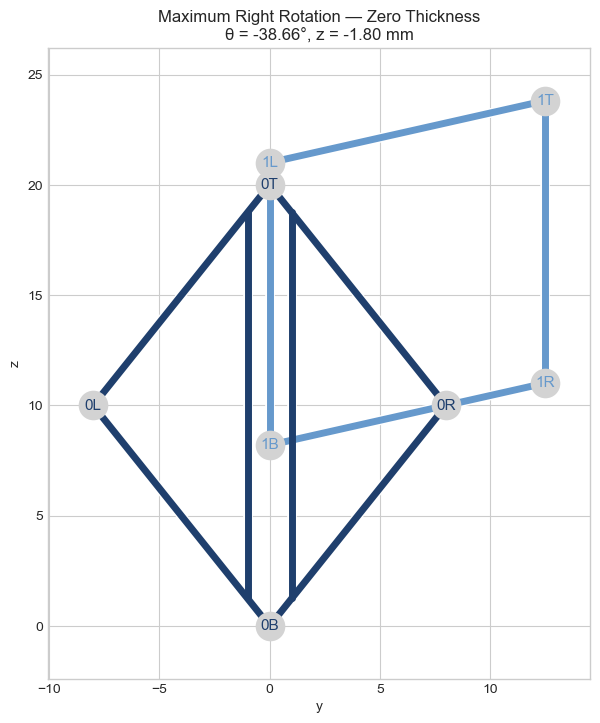

<Axes: title={'center': 'Maximum Right Rotation — Zero Thickness\nθ = -38.66°, z = -1.80 mm'}, xlabel='y', ylabel='z'>

In [42]:
right_limit_zero = find_right_max_rotation(
    two_unit_chain,
    contact_offset=0.0
)

plot_geometry(
    two_unit_chain,
    plot_title=(
        f"Maximum Right Rotation — Zero Thickness\n"
        f"θ = {right_limit_zero['theta_deg']:.2f}°, "
        f"z = {right_limit_zero['z_shift']:.2f} mm"
    )
)

Solver success: True
Physically valid: True
θ: -28.388048°
z shift: -1.215964 mm
Contact offset: 2.000000 mm
Reference side 1R1B–0R: +1
Reference side 1B1L–0T: +1
Signed gap 1R1B–0R: 2.000000000 mm
Oriented separation 1R1B–0R: 2.000000000 mm
Clearance 1R1B–0R: 0.000000000 mm
Signed gap 1B1L–0T: 2.000000000 mm
Oriented separation 1B1L–0T: 2.000000000 mm
Clearance 1B1L–0T: -0.000000000 mm
Residual norm: 1.256e-15


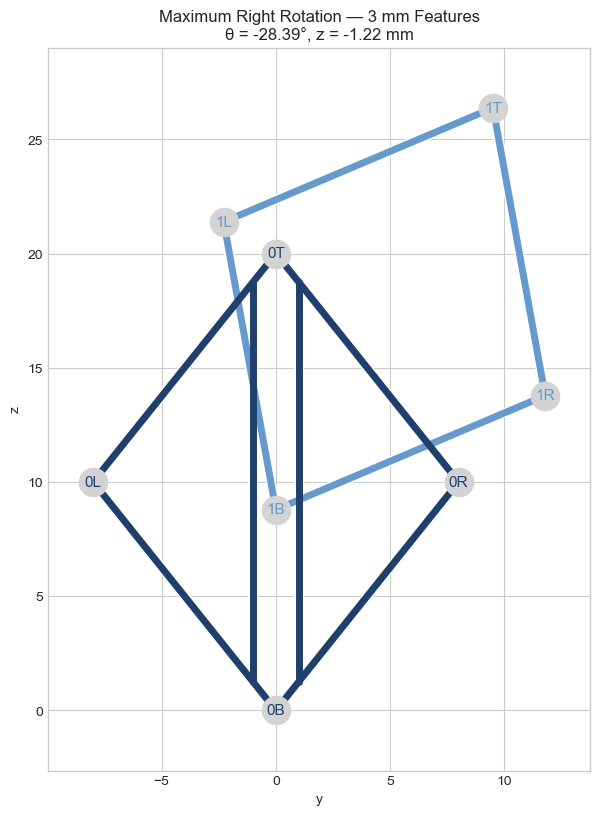

<Axes: title={'center': 'Maximum Right Rotation — 3 mm Features\nθ = -28.39°, z = -1.22 mm'}, xlabel='y', ylabel='z'>

In [43]:
node_diameter = 2.0
strut_width = 2.0

contact_offset = (
    node_diameter / 2
    + strut_width / 2
)

right_limit_thick = find_right_max_rotation(
    two_unit_chain,
    contact_offset=contact_offset
)

plot_geometry(
    two_unit_chain,
    plot_title=(
        f"Maximum Right Rotation — 3 mm Features\n"
        f"θ = {right_limit_thick['theta_deg']:.2f}°, "
        f"z = {right_limit_thick['z_shift']:.2f} mm"
    )
)

Solver success: True
Physically valid: True
θ: 38.659808°
z shift: -1.800000 mm
Contact offset: 0.000000 mm
Reference side 1B1L–0L: -1
Reference side 1R1B–0T: -1
Signed gap 1B1L–0L: 0.000000000 mm
Oriented separation 1B1L–0L: -0.000000000 mm
Clearance 1B1L–0L: -0.000000000 mm
Signed gap 1R1B–0T: 0.000000000 mm
Oriented separation 1R1B–0T: -0.000000000 mm
Clearance 1R1B–0T: -0.000000000 mm
Residual norm: 0.000e+00


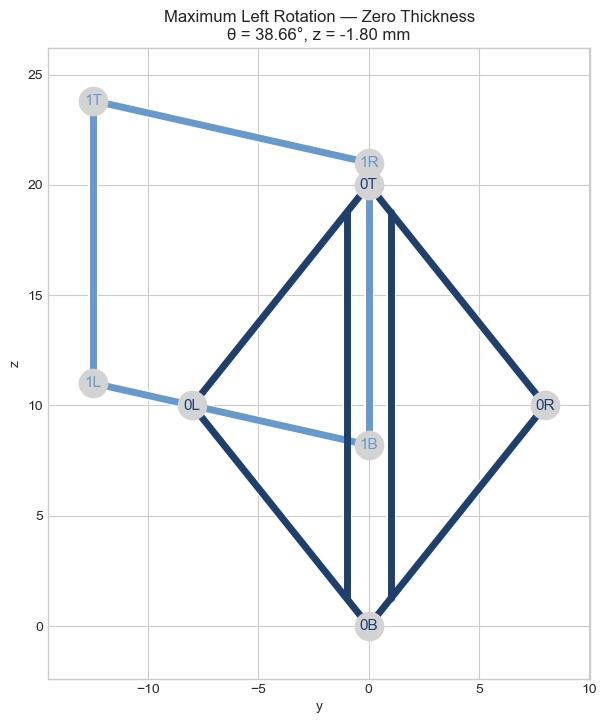

<Axes: title={'center': 'Maximum Left Rotation — Zero Thickness\nθ = 38.66°, z = -1.80 mm'}, xlabel='y', ylabel='z'>

In [44]:
left_limit_zero = find_left_max_rotation(
    two_unit_chain,
    contact_offset=0.0
)

plot_geometry(
    two_unit_chain,
    plot_title=(
        f"Maximum Left Rotation — Zero Thickness\n"
        f"θ = {left_limit_zero['theta_deg']:.2f}°, "
        f"z = {left_limit_zero['z_shift']:.2f} mm"
    )
)

Solver success: True
Physically valid: True
θ: 22.749271°
z shift: -0.943470 mm
Contact offset: 3.000000 mm
Reference side 1B1L–0L: -1
Reference side 1R1B–0T: -1
Signed gap 1B1L–0L: -3.000000000 mm
Oriented separation 1B1L–0L: 3.000000000 mm
Clearance 1B1L–0L: -0.000000000 mm
Signed gap 1R1B–0T: -3.000000000 mm
Oriented separation 1R1B–0T: 3.000000000 mm
Clearance 1R1B–0T: 0.000000000 mm
Residual norm: 1.601e-15


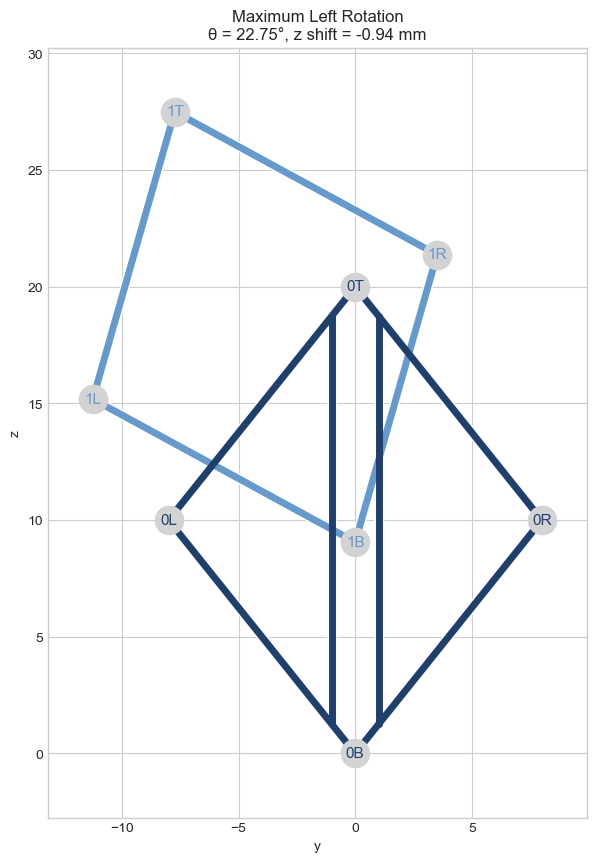

<Axes: title={'center': 'Maximum Left Rotation\nθ = 22.75°, z shift = -0.94 mm'}, xlabel='y', ylabel='z'>

In [45]:
#left_limit = find_left_max_rotation(two_unit_chain)

node_diameter = 3.0
strut_width = 3.0

contact_offset = (
    node_diameter / 2
    + strut_width / 2
)

left_limit = find_left_max_rotation(
    two_unit_chain,
    contact_offset=contact_offset
)

plot_geometry(
    two_unit_chain,
    plot_title=(
        f"Maximum Left Rotation\n"
        f"θ = {left_limit['theta_deg']:.2f}°, "
        f"z shift = {left_limit['z_shift']:.2f} mm"
    )
)

#### Test Finding Vertical Limits for 2-Unit Chain

In [46]:
top_zero = find_vertical_limit(
    two_unit_chain,
    direction="up",
    contact_offset=0.0
)

bottom_zero = find_vertical_limit(
    two_unit_chain,
    direction="down",
    contact_offset=0.0
)

Direction: up
Physically valid: True
θ: 0.000000°
z shift: 9.999999988 mm
Contact offset: 0.000000000 mm
Reference side 1B1L–0T: +1
Reference side 1R1B–0T: -1
Oriented separation 1B1L–0T: 0.000000007 mm
Clearance 1B1L–0T: 0.000000007 mm
Oriented separation 1R1B–0T: 0.000000007 mm
Clearance 1R1B–0T: 0.000000007 mm
Direction: down
Physically valid: True
θ: 0.000000°
z shift: -9.999999994 mm
Contact offset: 0.000000000 mm
Reference side 1B1L–0B: +1
Reference side 1R1B–0B: +1
Oriented separation 1B1L–0B: 0.000000006 mm
Clearance 1B1L–0B: 0.000000006 mm
Oriented separation 1R1B–0B: 0.000000006 mm
Clearance 1R1B–0B: 0.000000006 mm


Direction: up
Physically valid: True
θ: 0.000000°
z shift: 9.999999988 mm
Contact offset: 0.000000000 mm
Reference side 1B1L–0T: +1
Reference side 1R1B–0T: -1
Oriented separation 1B1L–0T: 0.000000007 mm
Clearance 1B1L–0T: 0.000000007 mm
Oriented separation 1R1B–0T: 0.000000007 mm
Clearance 1R1B–0T: 0.000000007 mm


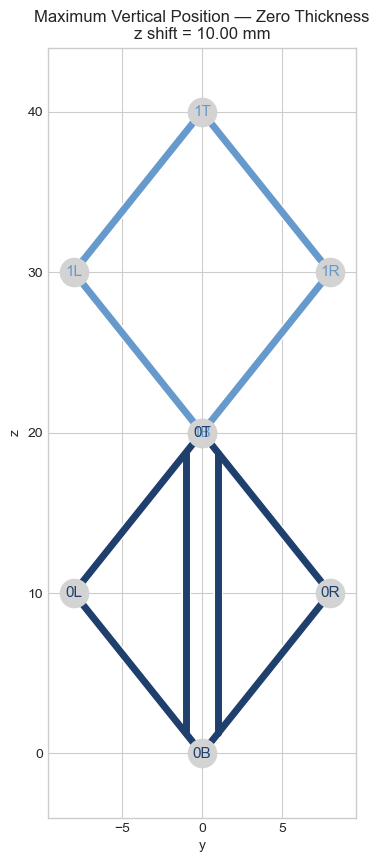

Direction: up
Physically valid: True
θ: 0.000000°
z shift: 5.197656822 mm
Contact offset: 3.000000000 mm
Reference side 1B1L–0T: +1
Reference side 1R1B–0T: -1
Oriented separation 1B1L–0T: 3.000000000 mm
Clearance 1B1L–0T: -0.000000000 mm
Oriented separation 1R1B–0T: 3.000000000 mm
Clearance 1R1B–0T: -0.000000000 mm


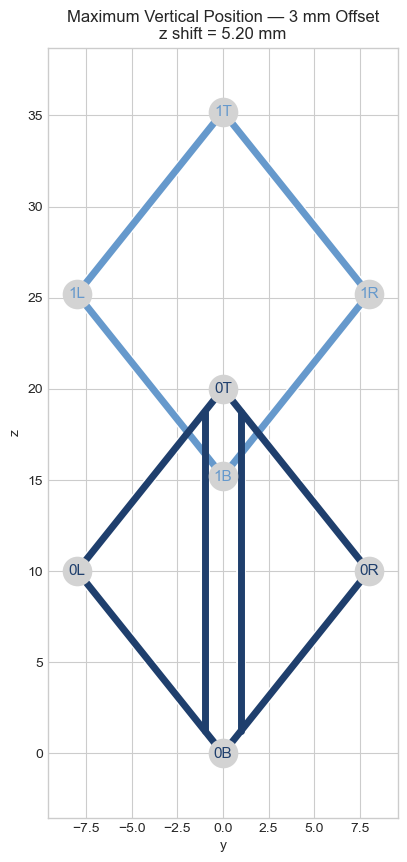

<Axes: title={'center': 'Maximum Vertical Position — 3 mm Offset\nz shift = 5.20 mm'}, xlabel='y', ylabel='z'>

In [47]:
top_zero = find_vertical_limit(
    two_unit_chain,
    direction="up",
    contact_offset=0.0
)

plot_geometry(
    two_unit_chain,
    plot_title=(
        "Maximum Vertical Position — Zero Thickness\n"
        f"z shift = {top_zero['z_shift']:.2f} mm"
    )
)

top_thick = find_vertical_limit(
    two_unit_chain,
    direction="up",
    contact_offset=3.0
)

plot_geometry(
    two_unit_chain,
    plot_title=(
        "Maximum Vertical Position — 3 mm Offset\n"
        f"z shift = {top_thick['z_shift']:.2f} mm"
    )
)

Direction: down
Physically valid: True
θ: 0.000000°
z shift: -9.999999994 mm
Contact offset: 0.000000000 mm
Reference side 1B1L–0B: +1
Reference side 1R1B–0B: +1
Oriented separation 1B1L–0B: 0.000000006 mm
Clearance 1B1L–0B: 0.000000006 mm
Oriented separation 1R1B–0B: 0.000000006 mm
Clearance 1R1B–0B: 0.000000006 mm


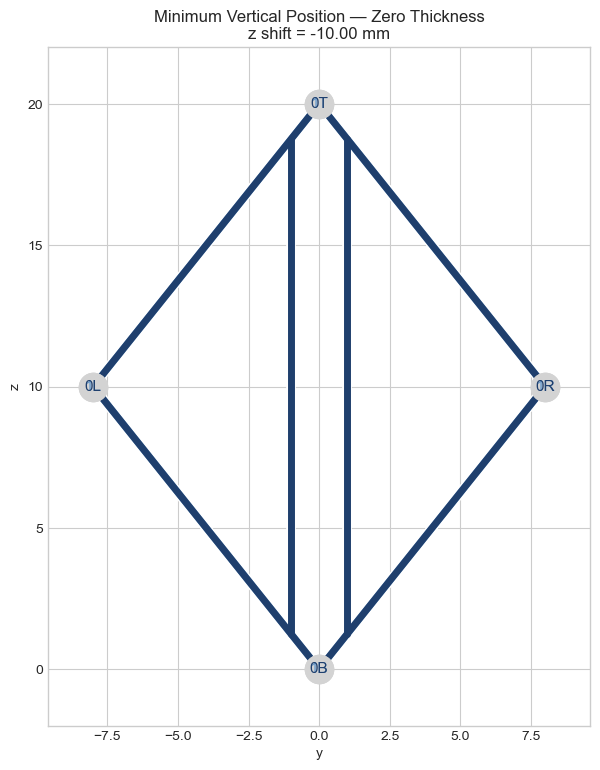

Direction: down
Physically valid: True
θ: 0.000000°
z shift: -6.999999994 mm
Contact offset: 3.000000000 mm
Reference side 1B1L–0B: +1
Reference side 1R1B–0B: +1
Oriented separation 1B1L–0B: 3.000000006 mm
Clearance 1B1L–0B: 0.000000006 mm
Oriented separation 1R1B–0B: 3.000000006 mm
Clearance 1R1B–0B: 0.000000006 mm


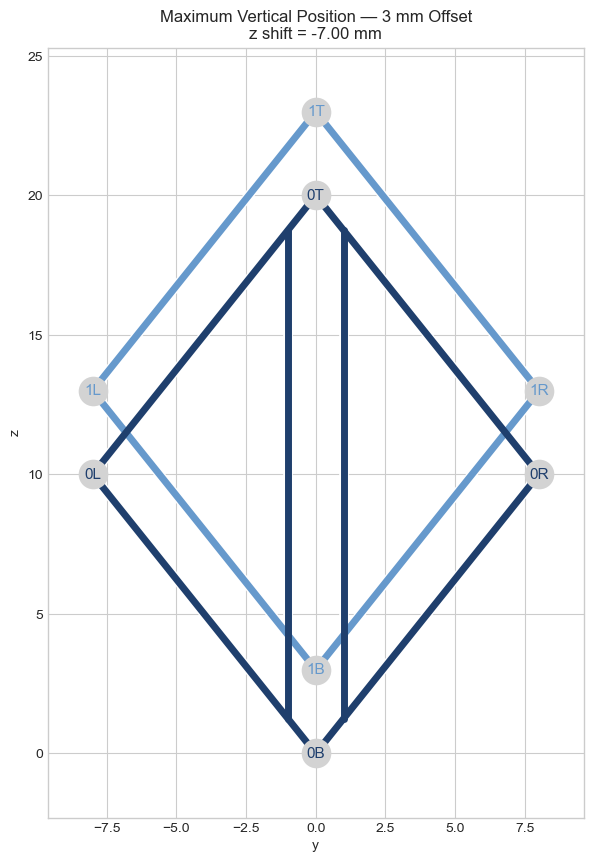

<Axes: title={'center': 'Maximum Vertical Position — 3 mm Offset\nz shift = -7.00 mm'}, xlabel='y', ylabel='z'>

In [48]:
bottom_zero = find_vertical_limit(
    two_unit_chain,
    direction="down",
    contact_offset=0.0
)

plot_geometry(
    two_unit_chain,
    plot_title=(
        "Minimum Vertical Position — Zero Thickness\n"
        f"z shift = {bottom_zero['z_shift']:.2f} mm"
    )
)

bottom_thick = find_vertical_limit(
    two_unit_chain,
    direction="down",
    contact_offset=3.0
)

plot_geometry(
    two_unit_chain,
    plot_title=(
        "Maximum Vertical Position — 3 mm Offset\n"
        f"z shift = {bottom_thick['z_shift']:.2f} mm"
    )
)

#### Get Workspace for Two-Unit Chain

### Find Max/Min Angle and Vertical Limits for Three-Unit Chain
- Build off of two-unit analysis of max/min angle and vertical limits (double contact points)
- Add segment-segment gap function evaluation
- Add Free-Railed gap function evaluation

## Get the Jacobian of the Active Gap Vector

In [49]:
def get_gap_jacobian(active_gap_vector, q=None, verbose=False):
    """
    Compute the Jacobian of the active gap vector.

    Parameters
    ----------
    active_gap_vector : sympy.Matrix
        One scalar gap expression per row.

    q : sympy.Matrix, optional
        Generalized coordinates. If omitted, all symbols appearing
        in the active gap vector are used.

    Returns
    -------
    J : sympy.Matrix
        Constraint Jacobian.

    q : sympy.Matrix
        Coordinates used to compute the Jacobian.
    """
    active_gap_vector = sp.Matrix(active_gap_vector)

    if q is None: # get all the variables in the active_gap_vector (these are our generalized coordinates)
        q = sp.Matrix(
            sorted(active_gap_vector.free_symbols, key=lambda s: s.name)
        )

    J = active_gap_vector.jacobian(q)
    
    if verbose:
        print(f"Active gap vector:")
        display(active_gap_vector)
        print("\n")
        print(f"Generalized coordinates:")
        display(q)
        print("\n")
        print(f"Active gap vector Jacobian:")
        display(J)
        print("\n")
        print("Jacobian dimensions: ")
        print(J.shape)
    
    return active_gap_vector.jacobian(q), q

In [50]:
J, q = get_gap_jacobian(active_gap_vector,verbose=True)

Active gap vector:


Matrix([[(-(A_1R_y - B_1B_y)*(A_1R_z - P_0T_z) + (A_1R_y - P_0T_y)*(A_1R_z - B_1B_z))/sqrt((A_1R_y - B_1B_y)**2 + (A_1R_z - B_1B_z)**2)]])



Generalized coordinates:


Matrix([
[A_1R_y],
[A_1R_z],
[B_1B_y],
[B_1B_z],
[P_0T_y],
[P_0T_z]])



Active gap vector Jacobian:


Matrix([[(-A_1R_y + B_1B_y)*(-(A_1R_y - B_1B_y)*(A_1R_z - P_0T_z) + (A_1R_y - P_0T_y)*(A_1R_z - B_1B_z))/((A_1R_y - B_1B_y)**2 + (A_1R_z - B_1B_z)**2)**(3/2) + (-B_1B_z + P_0T_z)/sqrt((A_1R_y - B_1B_y)**2 + (A_1R_z - B_1B_z)**2), (-A_1R_z + B_1B_z)*(-(A_1R_y - B_1B_y)*(A_1R_z - P_0T_z) + (A_1R_y - P_0T_y)*(A_1R_z - B_1B_z))/((A_1R_y - B_1B_y)**2 + (A_1R_z - B_1B_z)**2)**(3/2) + (B_1B_y - P_0T_y)/sqrt((A_1R_y - B_1B_y)**2 + (A_1R_z - B_1B_z)**2), (A_1R_y - B_1B_y)*(-(A_1R_y - B_1B_y)*(A_1R_z - P_0T_z) + (A_1R_y - P_0T_y)*(A_1R_z - B_1B_z))/((A_1R_y - B_1B_y)**2 + (A_1R_z - B_1B_z)**2)**(3/2) + (A_1R_z - P_0T_z)/sqrt((A_1R_y - B_1B_y)**2 + (A_1R_z - B_1B_z)**2), (-A_1R_y + P_0T_y)/sqrt((A_1R_y - B_1B_y)**2 + (A_1R_z - B_1B_z)**2) + (A_1R_z - B_1B_z)*(-(A_1R_y - B_1B_y)*(A_1R_z - P_0T_z) + (A_1R_y - P_0T_y)*(A_1R_z - B_1B_z))/((A_1R_y - B_1B_y)**2 + (A_1R_z - B_1B_z)**2)**(3/2), (-A_1R_z + B_1B_z)/sqrt((A_1R_y - B_1B_y)**2 + (A_1R_z - B_1B_z)**2), (A_1R_y - B_1B_y)/sqrt((A_1R_y - B_1B_y)*



Jacobian dimensions: 
(1, 6)


## Maybe...

### Unit Move Propagation methods

In [51]:
# TODO: Add a method to translate and/or rotate a free RAMM unit about its bottom node,
# then propagate the resulting rigid-body motion to all downstream units in the chain.

### Validity Checkers

In [52]:
# TODO: write a method that takes a chain and analyzes the validity of the chain